In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "5"   # 按你的机器选择 GPU
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# 可选：限制 JAX 占用显存比例
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.75"

import sys
from pathlib import Path

PROJECT_DIR = "/home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/var_boundary_sno_code"
sys.path.append(PROJECT_DIR)

import jax
import jax.numpy as jnp

from config_varboundary import VarBoundaryConfig
from train_varboundary import train_fe, train_fe_with_pool, train_ol_with_pool
from data_varboundary import sample_batch

print(jax.devices())

[CudaDevice(id=0)]


In [2]:
cfg = VarBoundaryConfig()

# 输出目录
cfg.out_dir = "/home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out"
cfg.run_name = "test1"

# PDE parameter range. If fixed k is desired, set k_min = k_max. maybe (0.2, 2.0).
cfg.k_min = 0.2
cfg.k_max = 2.0

# PI-sampler priors
cfg.sample_size = 128
cfg.num_repeats = 6

# Training
cfg.fe_steps = 300_000
cfg.ol_steps = 200_000

cfg.save_json()
print(cfg.output_dir)

/home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1


### 训练 FE

In [3]:
# 检查形状

key = jax.random.PRNGKey(cfg.seed)
batch = sample_batch(key, cfg)

print("pod_coords:", batch.pod_coords.shape)
print("probe_coords:", batch.probe_coords.shape)
print("pod_phys_coords:", batch.pod_phys_coords.shape)
print("probe_phys_coords:", batch.probe_phys_coords.shape)

print("u_pod:", batch.u_pod.shape)
print("f_pod:", batch.f_pod.shape)
print("u_probe:", batch.u_probe.shape)
print("f_probe:", batch.f_probe.shape)

print("boundary_coords:", batch.boundary_coords.shape)
print("boundary_flux:", batch.boundary_flux.shape)
print("k_values:", batch.k_values.shape)

pod_coords: (4096, 2)
probe_coords: (1024, 2)
pod_phys_coords: (192, 4096, 2)
probe_phys_coords: (192, 1024, 2)
u_pod: (192, 4096)
f_pod: (192, 4096)
u_probe: (192, 1024)
f_probe: (192, 1024)
boundary_coords: (192, 128, 2)
boundary_flux: (192, 128)
k_values: (192,)


In [3]:
fe_state, normalizer = train_fe_with_pool(cfg)

[FE] Reusing existing training pool: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/fe_pool.pkl.gz
[Pool] loaded 1000 batches from: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/fe_pool.pkl.gz
[FE] Reusing existing field normalizer from: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1
[Normalizer] {'mean_u': -1.591348700458184e-05, 'std_u': 0.28429415822029114, 'mean_f': -0.008345461450517178, 'std_f': 57.519596099853516}


E0528 10:57:54.257538  104592 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[4096,512]{1,0} fusion(args_0_.1, args_1_.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0528 10:57:54.257619  104592 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[4096,514]{1,0} parameter(0)
  parameter_1 = f32[514,512]{1,0} parameter(1)
  ROOT dot_general.0 = f32[4096,512]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["64"]}
}
E0528 10:57:54.275461  104593 x

[FE 0000000] pool_idx=0860, loss=3.057e+00, RL2_u=1.697e+01, RL2_f=1.456e+01
[FE 0000500] pool_idx=0048, loss=9.178e-01, RL2_u=5.903e-01, RL2_f=9.480e-01
[FE 0001000] pool_idx=0270, loss=9.245e-01, RL2_u=5.281e-01, RL2_f=8.424e-01
[FE 0001500] pool_idx=0392, loss=1.150e+00, RL2_u=5.447e-01, RL2_f=8.000e-01
[FE 0002000] pool_idx=0616, loss=1.768e-01, RL2_u=2.423e-01, RL2_f=3.802e-01
[FE 0002500] pool_idx=0861, loss=9.848e-01, RL2_u=4.895e-01, RL2_f=9.484e-01
[FE 0003000] pool_idx=0719, loss=7.788e-02, RL2_u=1.131e-01, RL2_f=2.720e-01
[FE 0003500] pool_idx=0986, loss=6.288e-02, RL2_u=8.682e-02, RL2_f=2.242e-01
[FE 0004000] pool_idx=0892, loss=5.299e-02, RL2_u=8.646e-02, RL2_f=2.271e-01
[FE 0004500] pool_idx=0826, loss=8.059e-02, RL2_u=9.285e-02, RL2_f=2.483e-01
[FE 0005000] pool_idx=0537, loss=5.705e-02, RL2_u=1.050e-01, RL2_f=2.277e-01
[FE 0005500] pool_idx=0082, loss=4.617e-02, RL2_u=1.004e-01, RL2_f=2.188e-01
[FE 0006000] pool_idx=0360, loss=4.299e-02, RL2_u=1.118e-01, RL2_f=1.926e-01

### 检查并导出 FE 重构效果

In [4]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "5"   
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.75"

import sys
import copy
from pathlib import Path

import numpy as np
import jax
import jax.numpy as jnp
from flax import serialization
from scipy.io import savemat

PROJECT_DIR = "/home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/var_boundary_sno_code"
sys.path.append(PROJECT_DIR)

from config_varboundary import VarBoundaryConfig
from data_varboundary import (
    sample_batch,
    normalize_u,
    normalize_f,
    denormalize_u,
    denormalize_f,
)
from models_varboundary import FunctionEncoder
from train_varboundary import (
    create_fe_state,
    load_field_normalizer,
    rl2_error,
)

print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


In [5]:
cfg = VarBoundaryConfig()

# 输出目录
cfg.out_dir = "/home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out"
cfg.run_name = "test1"

# PDE parameter range. If fixed k is desired, set k_min = k_max. maybe (0.2, 2.0).
cfg.k_min = 0.2
cfg.k_max = 2.0

# PI-sampler priors
cfg.sample_size = 128
cfg.num_repeats = 6

# Training
cfg.fe_steps = 300_000
cfg.ol_steps = 200_000

out_dir = cfg.output_dir
print("Output dir:", out_dir)

Output dir: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1


In [6]:
normalizer = load_field_normalizer(out_dir)

print("[Normalizer]")
print("mean_u =", float(normalizer.mean_u))
print("std_u  =", float(normalizer.std_u))
print("mean_f =", float(normalizer.mean_f))
print("std_f  =", float(normalizer.std_f))


key = jax.random.PRNGKey(cfg.seed + 20260528)
key, key_init, key_batch = jax.random.split(key, 3)

fe_state, fe_model = create_fe_state(cfg, key_init)

param_path = out_dir / "fe_params.msgpack"

if not param_path.exists():
    raise FileNotFoundError(f"Cannot find FE parameter file: {param_path}")

fe_params = serialization.from_bytes(
    fe_state.params,
    param_path.read_bytes(),
)

fe_state = fe_state.replace(params=fe_params)

print("Loaded FE params from:", param_path)

[Normalizer]
mean_u = -1.591348700458184e-05
std_u  = 0.28429415822029114
mean_f = -0.008345461450517178
std_f  = 57.519596099853516
Loaded FE params from: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/fe_params.msgpack


In [7]:
n_test = 100

cfg_eval = copy.deepcopy(cfg)

# 为了精确生成 100 个样本，建议 evaluation 时 num_repeats = 1
cfg_eval.num_repeats = 1
cfg_eval.sample_size = n_test

# 如果显存不够，可以改成小 batch 分多次生成，下面先给一次性版本
batch = sample_batch(key_batch, cfg_eval)

print("========== batch shapes ==========")
print("pod_coords:", batch.pod_coords.shape)
print("pod_phys_coords:", batch.pod_phys_coords.shape)
print("u_pod:", batch.u_pod.shape)
print("f_pod:", batch.f_pod.shape)
print("boundary_coords:", batch.boundary_coords.shape)
print("boundary_flux:", batch.boundary_flux.shape)
print("k_values:", batch.k_values.shape)

========== batch shapes ==========
pod_coords: (4096, 2)
pod_phys_coords: (100, 4096, 2)
u_pod: (100, 4096)
f_pod: (100, 4096)
boundary_coords: (100, 128, 2)
boundary_flux: (100, 128)
k_values: (100,)


In [8]:
# ============================================================
# 1. Normalize FE branch input
# ============================================================
u_pod_norm = normalize_u(batch.u_pod, normalizer)
f_pod_norm = normalize_f(batch.f_pod, normalizer)

# ============================================================
# 2. Encode to latent coefficients
# ============================================================
latent_u = fe_state.apply_fn(
    {"params": fe_state.params},
    u_pod_norm,
    method=FunctionEncoder.encode_u,
)

latent_f = fe_state.apply_fn(
    {"params": fe_state.params},
    f_pod_norm,
    method=FunctionEncoder.encode_f,
)

print("latent_u:", latent_u.shape)
print("latent_f:", latent_f.shape)

# ============================================================
# 3. Reconstruct on canonical pod grid
# ============================================================
u_recon_norm = fe_state.apply_fn(
    {"params": fe_state.params},
    latent_u,
    batch.pod_coords,
    method=FunctionEncoder.reconstruct,
)

f_recon_norm = fe_state.apply_fn(
    {"params": fe_state.params},
    latent_f,
    batch.pod_coords,
    method=FunctionEncoder.reconstruct,
)

# ============================================================
# 4. Denormalize back to physical scale
# ============================================================
u_recon = denormalize_u(u_recon_norm, normalizer)
f_recon = denormalize_f(f_recon_norm, normalizer)

print("u_recon:", u_recon.shape)
print("f_recon:", f_recon.shape)

latent_u: (100, 512)
latent_f: (100, 512)
u_recon: (100, 4096)
f_recon: (100, 4096)


In [9]:
err_u_each = rl2_error(u_recon, batch.u_pod)
err_f_each = rl2_error(f_recon, batch.f_pod)

print("========== FE reconstruction diagnostic ==========")
print("mean RL2_u:", float(err_u_each.mean()))
print("max  RL2_u:", float(err_u_each.max()))
print("min  RL2_u:", float(err_u_each.min()))

print("mean RL2_f:", float(err_f_each.mean()))
print("max  RL2_f:", float(err_f_each.max()))
print("min  RL2_f:", float(err_f_each.min()))

========== FE reconstruction diagnostic ==========
mean RL2_u: 0.004940507933497429
max  RL2_u: 0.015941983088850975
min  RL2_u: 0.001684530288912356
mean RL2_f: 0.0142136225476861
max  RL2_f: 0.055102553218603134
min  RL2_f: 0.005763490684330463


In [10]:
def to_numpy(x):
    return np.asarray(jax.device_get(x))


Nr = cfg_eval.radial_size
Nt = cfg_eval.theta_size
Npod = Nr * Nt

assert batch.pod_coords.shape[0] == Npod
assert batch.u_pod.shape[1] == Npod
assert batch.f_pod.shape[1] == Npod

# 标准域坐标
pod_coords_np = to_numpy(batch.pod_coords)        # [Npod, 2]
xhat_grid = pod_coords_np[:, 0].reshape(Nr, Nt)
yhat_grid = pod_coords_np[:, 1].reshape(Nr, Nt)

# 物理域坐标，每个样本不同
pod_phys_np = to_numpy(batch.pod_phys_coords)     # [B, Npod, 2]
x_phys_grid = pod_phys_np[:, :, 0].reshape(n_test, Nr, Nt)
y_phys_grid = pod_phys_np[:, :, 1].reshape(n_test, Nr, Nt)

# 场变量
u_true_np = to_numpy(batch.u_pod)
f_true_np = to_numpy(batch.f_pod)
u_recon_np = to_numpy(u_recon)
f_recon_np = to_numpy(f_recon)

u_true_grid = u_true_np.reshape(n_test, Nr, Nt)
f_true_grid = f_true_np.reshape(n_test, Nr, Nt)
u_recon_grid = u_recon_np.reshape(n_test, Nr, Nt)
f_recon_grid = f_recon_np.reshape(n_test, Nr, Nt)

u_error_grid = u_recon_grid - u_true_grid
f_error_grid = f_recon_grid - f_true_grid

boundary_coords_np = to_numpy(batch.boundary_coords)   # [B, Nt, 2]
boundary_flux_np = to_numpy(batch.boundary_flux)       # [B, Nt]
k_values_np = to_numpy(batch.k_values)

err_u_each_np = to_numpy(err_u_each)
err_f_each_np = to_numpy(err_f_each)

In [11]:
mat_path = out_dir / "fe_reconstruction_100_varboundary.mat"

savemat(
    mat_path,
    {
        # Metadata
        "n_test": np.array([[n_test]]),
        "radial_size": np.array([[Nr]]),
        "theta_size": np.array([[Nt]]),
        "n_basis": np.array([[cfg.n_basis]]),

        # Canonical coordinates
        "pod_coords": pod_coords_np,             # [Npod, 2]
        "xhat_grid": xhat_grid,                  # [Nr, Nt]
        "yhat_grid": yhat_grid,                  # [Nr, Nt]

        # Physical coordinates, sample-dependent
        "pod_phys_coords": pod_phys_np,          # [B, Npod, 2]
        "x_phys_grid": x_phys_grid,              # [B, Nr, Nt]
        "y_phys_grid": y_phys_grid,              # [B, Nr, Nt]

        # True fields
        "u_true_pod": u_true_np,                 # [B, Npod]
        "f_true_pod": f_true_np,
        "u_true_grid": u_true_grid,              # [B, Nr, Nt]
        "f_true_grid": f_true_grid,

        # FE reconstructed fields
        "u_recon_pod": u_recon_np,               # [B, Npod]
        "f_recon_pod": f_recon_np,
        "u_recon_grid": u_recon_grid,            # [B, Nr, Nt]
        "f_recon_grid": f_recon_grid,

        # Errors
        "u_error_grid": u_error_grid,
        "f_error_grid": f_error_grid,
        "err_u_each": err_u_each_np[:, None],
        "err_f_each": err_f_each_np[:, None],
        "mean_err_u": np.array([[float(err_u_each.mean())]]),
        "mean_err_f": np.array([[float(err_f_each.mean())]]),
        "max_err_u": np.array([[float(err_u_each.max())]]),
        "max_err_f": np.array([[float(err_f_each.max())]]),

        # Boundary and parameters
        "boundary_coords": boundary_coords_np,   # [B, Nt, 2]
        "boundary_flux": boundary_flux_np,       # [B, Nt]
        "k_values": k_values_np[:, None],        # [B, 1]

        # Normalizer
        "norm_mean_u": np.array([[float(normalizer.mean_u)]]),
        "norm_std_u": np.array([[float(normalizer.std_u)]]),
        "norm_mean_f": np.array([[float(normalizer.mean_f)]]),
        "norm_std_f": np.array([[float(normalizer.std_f)]]),
    },
    do_compression=True,
)

print("Saved MATLAB file to:", mat_path)

Saved MATLAB file to: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/fe_reconstruction_100_varboundary.mat


### 训练 transformer

In [3]:
ol_state = train_ol_with_pool(cfg)

[Normalizer] {'mean_u': -1.591348700458184e-05, 'std_u': 0.28429415822029114, 'mean_f': -0.008345461450517178, 'std_f': 57.519596099853516}


E0528 16:34:24.044414  117695 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[4096,512]{1,0} fusion(args_0_.1, args_1_.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0528 16:34:24.044550  117695 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[4096,514]{1,0} parameter(0)
  parameter_1 = f32[514,512]{1,0} parameter(1)
  ROOT dot_general.0 = f32[4096,512]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["64"]}
}
E0528 16:34:24.064671  117702 x

[OL] Loaded FE params from: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/fe_params.msgpack
[OL] Loading training pool from: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/fe_pool.pkl.gz
[Pool] loaded 1000 batches from: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/fe_pool.pkl.gz
[OL] Loaded 1000 batches.


E0528 16:42:10.260566  117688 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.1 = f32[8,65,65]{2,1,0} fusion(bitcast.11, bitcast.10), kind=kCustom, calls=gemm_fusion_dot.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0528 16:42:10.260696  117688 xtile_compiler.cc:401] Computation: gemm_fusion_dot.1_computation.clone {
  parameter_0 = f32[65,8,64]{2,1,0} parameter(0)
  transpose.4 = f32[8,65,64]{2,1,0} transpose(parameter_0), dimensions={1,0,2}
  parameter_1 = f32[65,8,64]{2,1,0} parameter(1)
  transpose.5 = f32[8,64,65]{2,1,0} transpose(parameter_1), dimensions={1,2,0}
  ROOT dot.2 = f32[8,65,65]{2,1,0} dot(trans

[OL 0000000] pool_idx=0173, loss=7.278e-01, RL2_u=3.389e+00, RL2_u_max=1.085e+01
[OL 0000500] pool_idx=0231, loss=1.640e-02, RL2_u=8.418e-01, RL2_u_max=2.071e+00
[OL 0001000] pool_idx=0114, loss=8.655e-03, RL2_u=5.409e-01, RL2_u_max=1.189e+00
[OL 0001500] pool_idx=0190, loss=5.621e-03, RL2_u=4.490e-01, RL2_u_max=1.157e+00
[OL 0002000] pool_idx=0422, loss=4.361e-03, RL2_u=4.047e-01, RL2_u_max=1.084e+00
[OL 0002500] pool_idx=0040, loss=3.973e-03, RL2_u=3.786e-01, RL2_u_max=9.491e-01
[OL 0003000] pool_idx=0972, loss=3.236e-03, RL2_u=3.404e-01, RL2_u_max=9.297e-01
[OL 0003500] pool_idx=0447, loss=2.915e-03, RL2_u=3.197e-01, RL2_u_max=7.943e-01
[OL 0004000] pool_idx=0262, loss=2.381e-03, RL2_u=3.129e-01, RL2_u_max=1.050e+00
[OL 0004500] pool_idx=0571, loss=2.120e-03, RL2_u=2.667e-01, RL2_u_max=8.556e-01
[OL 0005000] pool_idx=0628, loss=2.179e-03, RL2_u=2.736e-01, RL2_u_max=9.699e-01
[OL 0005500] pool_idx=0075, loss=1.563e-03, RL2_u=2.210e-01, RL2_u_max=5.880e-01
[OL 0006000] pool_idx=0941, 

### 检查 transformer 预测效果

In [5]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "5"   
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.75"

import sys
import copy
from pathlib import Path

import numpy as np
import jax
import jax.numpy as jnp
from flax import serialization
from scipy.io import savemat

PROJECT_DIR = "/home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/var_boundary_sno_code"
sys.path.append(PROJECT_DIR)

from config_varboundary import VarBoundaryConfig
from data_varboundary import (
    sample_batch,
    normalize_u,
    normalize_f,
    denormalize_u,
    denormalize_f,
    make_source_tokens,
    make_condition_tokens,
)
from models_varboundary import FunctionEncoder
from train_varboundary import (
    create_fe_state,
    create_ol_state,
    load_field_normalizer,
    rl2_error,
)

print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


In [6]:
cfg = VarBoundaryConfig()

# 输出目录
cfg.out_dir = "/home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out"
cfg.run_name = "test1"

# PDE parameter range. If fixed k is desired, set k_min = k_max. maybe (0.2, 2.0).
cfg.k_min = 0.2
cfg.k_max = 2.0

# PI-sampler priors
cfg.sample_size = 128
cfg.num_repeats = 6

# Training
cfg.fe_steps = 300_000
cfg.ol_steps = 200_000

out_dir = cfg.output_dir
print("Output dir:", out_dir)

Output dir: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1


In [7]:
normalizer = load_field_normalizer(out_dir)

print("[Normalizer]")
print("mean_u =", float(normalizer.mean_u))
print("std_u  =", float(normalizer.std_u))
print("mean_f =", float(normalizer.mean_f))
print("std_f  =", float(normalizer.std_f))


key = jax.random.PRNGKey(cfg.seed + 20260529)
key, key_fe_init, key_ol_init, key_batch = jax.random.split(key, 4)

fe_state, fe_model = create_fe_state(cfg, key_fe_init)

fe_path = out_dir / "fe_params.msgpack"
if not fe_path.exists():
    raise FileNotFoundError(f"Cannot find trained FE params: {fe_path}")

fe_params = serialization.from_bytes(
    fe_state.params,
    fe_path.read_bytes(),
)

fe_state = fe_state.replace(params=fe_params)

print("Loaded FE params from:", fe_path)


ol_state, ol_model = create_ol_state(cfg, key_ol_init)

ol_path = out_dir / "ol_params.msgpack"
if not ol_path.exists():
    raise FileNotFoundError(f"Cannot find trained OL params: {ol_path}")

ol_params = serialization.from_bytes(
    ol_state.params,
    ol_path.read_bytes(),
)

ol_state = ol_state.replace(params=ol_params)

print("Loaded OL params from:", ol_path)

[Normalizer]
mean_u = -1.591348700458184e-05
std_u  = 0.28429415822029114
mean_f = -0.008345461450517178
std_f  = 57.519596099853516
Loaded FE params from: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/fe_params.msgpack
Loaded OL params from: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/ol_params.msgpack


In [8]:
n_test = 100

cfg_eval = copy.deepcopy(cfg)

# 为了精确生成 100 个样本，建议 evaluation 时 num_repeats = 1
cfg_eval.num_repeats = 1
cfg_eval.sample_size = n_test

# 如果显存不够，可以改成小 batch 分多次生成，下面先给一次性版本
batch = sample_batch(key_batch, cfg_eval)

print("========== batch shapes ==========")
print("pod_coords:", batch.pod_coords.shape)
print("pod_phys_coords:", batch.pod_phys_coords.shape)
print("u_pod:", batch.u_pod.shape)
print("f_pod:", batch.f_pod.shape)
print("boundary_coords:", batch.boundary_coords.shape)
print("boundary_flux:", batch.boundary_flux.shape)
print("k_values:", batch.k_values.shape)

========== batch shapes ==========
pod_coords: (4096, 2)
pod_phys_coords: (100, 4096, 2)
u_pod: (100, 4096)
f_pod: (100, 4096)
boundary_coords: (100, 128, 2)
boundary_flux: (100, 128)
k_values: (100,)


In [9]:
# ============================================================
# 1. Normalize input fields
# ============================================================
u_pod_norm = normalize_u(batch.u_pod, normalizer)
f_pod_norm = normalize_f(batch.f_pod, normalizer)

# ============================================================
# 2. FE encode f and u
# ============================================================
latent_f = fe_state.apply_fn(
    {"params": fe_state.params},
    f_pod_norm,
    method=FunctionEncoder.encode_f,
)

target_u_latent = fe_state.apply_fn(
    {"params": fe_state.params},
    u_pod_norm,
    method=FunctionEncoder.encode_u,
)

# ============================================================
# 3. Build Transformer tokens
# ============================================================
f_tokens = make_source_tokens(latent_f, cfg)
bc_tokens = make_condition_tokens(batch, cfg)

# ============================================================
# 4. Transformer predicts u latent
# ============================================================
pred_u_latent = ol_state.apply_fn(
    {"params": ol_state.params},
    f_tokens,
    bc_tokens,
    batch.k_values,
)

# ============================================================
# 5. Decode predicted latent through FE trunk
# ============================================================
u_pred_norm = fe_state.apply_fn(
    {"params": fe_state.params},
    pred_u_latent,
    batch.pod_coords,
    method=FunctionEncoder.reconstruct,
)

u_pred = denormalize_u(u_pred_norm, normalizer)

print("latent_f:", latent_f.shape)
print("target_u_latent:", target_u_latent.shape)
print("pred_u_latent:", pred_u_latent.shape)
print("u_pred:", u_pred.shape)

latent_f: (100, 512)
target_u_latent: (100, 512)
pred_u_latent: (100, 512)
u_pred: (100, 4096)


In [10]:
# ============================================================
# FE oracle reconstruction of u_true
# ============================================================
u_fe_recon_norm = fe_state.apply_fn(
    {"params": fe_state.params},
    target_u_latent,
    batch.pod_coords,
    method=FunctionEncoder.reconstruct,
)

u_fe_recon = denormalize_u(u_fe_recon_norm, normalizer)

# ============================================================
# Optional: FE reconstruction of input f
# ============================================================
f_fe_recon_norm = fe_state.apply_fn(
    {"params": fe_state.params},
    latent_f,
    batch.pod_coords,
    method=FunctionEncoder.reconstruct,
)

f_fe_recon = denormalize_f(f_fe_recon_norm, normalizer)

In [11]:
# Transformer + FE final prediction error
err_u_pred_each = rl2_error(u_pred, batch.u_pod)

# FE oracle reconstruction error
err_u_fe_each = rl2_error(u_fe_recon, batch.u_pod)

# FE f reconstruction error
err_f_fe_each = rl2_error(f_fe_recon, batch.f_pod)

# Latent-space relative error
err_latent_each = jnp.linalg.norm(
    pred_u_latent - target_u_latent,
    axis=-1,
) / (jnp.linalg.norm(target_u_latent, axis=-1) + 1e-12)

print("========== Transformer + FE test diagnostic ==========")
print("mean RL2_u_pred:", float(jnp.mean(err_u_pred_each)))
print("max  RL2_u_pred:", float(jnp.max(err_u_pred_each)))
print("min  RL2_u_pred:", float(jnp.min(err_u_pred_each)))

print("mean RL2_u_FE_recon:", float(jnp.mean(err_u_fe_each)))
print("mean RL2_f_FE_recon:", float(jnp.mean(err_f_fe_each)))
print("mean RL2_latent:", float(jnp.mean(err_latent_each)))

========== Transformer + FE test diagnostic ==========
mean RL2_u_pred: 0.013936772011220455
max  RL2_u_pred: 0.047307901084423065
min  RL2_u_pred: 0.0040296949446201324
mean RL2_u_FE_recon: 0.005519444588571787
mean RL2_f_FE_recon: 0.015093719586730003
mean RL2_latent: 0.019793247804045677


In [12]:
def to_numpy(x):
    return np.asarray(jax.device_get(x))


Nr = cfg_eval.radial_size
Nt = cfg_eval.theta_size
Npod = Nr * Nt

assert batch.pod_coords.shape[0] == Npod
assert batch.u_pod.shape[1] == Npod
assert batch.f_pod.shape[1] == Npod

# Canonical coordinates
pod_coords_np = to_numpy(batch.pod_coords)        # [Npod, 2]
xhat_grid = pod_coords_np[:, 0].reshape(Nr, Nt)
yhat_grid = pod_coords_np[:, 1].reshape(Nr, Nt)

# Physical coordinates
pod_phys_np = to_numpy(batch.pod_phys_coords)     # [B, Npod, 2]
x_phys_grid = pod_phys_np[:, :, 0].reshape(n_test, Nr, Nt)
y_phys_grid = pod_phys_np[:, :, 1].reshape(n_test, Nr, Nt)

# True fields
u_true_np = to_numpy(batch.u_pod)
f_true_np = to_numpy(batch.f_pod)

# Predictions and reconstructions
u_pred_np = to_numpy(u_pred)
u_fe_recon_np = to_numpy(u_fe_recon)
f_fe_recon_np = to_numpy(f_fe_recon)

# Grid fields
u_true_grid = u_true_np.reshape(n_test, Nr, Nt)
f_true_grid = f_true_np.reshape(n_test, Nr, Nt)

u_pred_grid = u_pred_np.reshape(n_test, Nr, Nt)
u_fe_recon_grid = u_fe_recon_np.reshape(n_test, Nr, Nt)
f_fe_recon_grid = f_fe_recon_np.reshape(n_test, Nr, Nt)

u_pred_abs_error_grid = np.abs(u_pred_grid - u_true_grid)
u_fe_abs_error_grid = np.abs(u_fe_recon_grid - u_true_grid)
f_fe_abs_error_grid = np.abs(f_fe_recon_grid - f_true_grid)

# Boundary
boundary_coords_np = to_numpy(batch.boundary_coords)
boundary_flux_np = to_numpy(batch.boundary_flux)

# Parameters and errors
k_values_np = to_numpy(batch.k_values)

err_u_pred_each_np = to_numpy(err_u_pred_each)
err_u_fe_each_np = to_numpy(err_u_fe_each)
err_f_fe_each_np = to_numpy(err_f_fe_each)
err_latent_each_np = to_numpy(err_latent_each)

latent_f_np = to_numpy(latent_f)
target_u_latent_np = to_numpy(target_u_latent)
pred_u_latent_np = to_numpy(pred_u_latent)

In [13]:
mat_path = out_dir / "ol_transformer_fe_test_100_varboundary.mat"

savemat(
    mat_path,
    {
        # Metadata
        "n_test": np.array([[n_test]]),
        "radial_size": np.array([[Nr]]),
        "theta_size": np.array([[Nt]]),
        "n_basis": np.array([[cfg.n_basis]]),

        # Canonical coordinates
        "pod_coords": pod_coords_np,              # [Npod, 2]
        "xhat_grid": xhat_grid,                   # [Nr, Nt]
        "yhat_grid": yhat_grid,                   # [Nr, Nt]

        # Physical coordinates
        "pod_phys_coords": pod_phys_np,           # [B, Npod, 2]
        "x_phys_grid": x_phys_grid,               # [B, Nr, Nt]
        "y_phys_grid": y_phys_grid,               # [B, Nr, Nt]

        # True fields
        "u_true_pod": u_true_np,                  # [B, Npod]
        "f_true_pod": f_true_np,
        "u_true_grid": u_true_grid,               # [B, Nr, Nt]
        "f_true_grid": f_true_grid,

        # Transformer + FE prediction
        "u_pred_pod": u_pred_np,                  # [B, Npod]
        "u_pred_grid": u_pred_grid,               # [B, Nr, Nt]
        "u_pred_abs_error_grid": u_pred_abs_error_grid,

        # FE oracle reconstruction
        "u_fe_recon_pod": u_fe_recon_np,
        "u_fe_recon_grid": u_fe_recon_grid,
        "u_fe_abs_error_grid": u_fe_abs_error_grid,

        # FE reconstruction of f
        "f_fe_recon_pod": f_fe_recon_np,
        "f_fe_recon_grid": f_fe_recon_grid,
        "f_fe_abs_error_grid": f_fe_abs_error_grid,

        # Latents
        "latent_f": latent_f_np,
        "target_u_latent": target_u_latent_np,
        "pred_u_latent": pred_u_latent_np,

        # Errors
        "err_u_pred_each": err_u_pred_each_np[:, None],
        "err_u_fe_each": err_u_fe_each_np[:, None],
        "err_f_fe_each": err_f_fe_each_np[:, None],
        "err_latent_each": err_latent_each_np[:, None],

        "mean_err_u_pred": np.array([[float(jnp.mean(err_u_pred_each))]]),
        "max_err_u_pred": np.array([[float(jnp.max(err_u_pred_each))]]),
        "mean_err_u_fe": np.array([[float(jnp.mean(err_u_fe_each))]]),
        "mean_err_f_fe": np.array([[float(jnp.mean(err_f_fe_each))]]),
        "mean_err_latent": np.array([[float(jnp.mean(err_latent_each))]]),

        # Boundary and parameters
        "boundary_coords": boundary_coords_np,    # [B, Nt, 2]
        "boundary_flux": boundary_flux_np,        # [B, Nt]
        "k_values": k_values_np[:, None],         # [B, 1]

        # Normalizer
        "norm_mean_u": np.array([[float(normalizer.mean_u)]]),
        "norm_std_u": np.array([[float(normalizer.std_u)]]),
        "norm_mean_f": np.array([[float(normalizer.mean_f)]]),
        "norm_std_f": np.array([[float(normalizer.std_f)]]),
    },
    do_compression=True,
)

print("Saved MATLAB file to:", mat_path)

Saved MATLAB file to: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/ol_transformer_fe_test_100_varboundary.mat


### 内边界为圆形时预测压力分布

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "5"   
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.75"

import sys
from pathlib import Path
import numpy as np

import jax
import jax.numpy as jnp
from flax import serialization
from scipy.io import savemat

PROJECT_DIR = "/home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/var_boundary_sno_code"
sys.path.append(PROJECT_DIR)

from config_varboundary import VarBoundaryConfig
from data_varboundary import (
    SampleBatch,
    GeometryParams,
    make_canonical_grid,
    make_theta,
    normalize_f,
    denormalize_u,
    make_source_tokens,
    make_condition_tokens,
)
from models_varboundary import FunctionEncoder
from train_varboundary import (
    create_fe_state,
    create_ol_state,
    load_field_normalizer,
)

print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


In [2]:
cfg = VarBoundaryConfig()

# 输出目录
cfg.out_dir = "/home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out"
cfg.run_name = "test1"

# PDE parameter range. If fixed k is desired, set k_min = k_max. maybe (0.2, 2.0).
cfg.k_min = 0.2
cfg.k_max = 2.0

# PI-sampler priors
cfg.sample_size = 128
cfg.num_repeats = 6

# Training
cfg.fe_steps = 300_000
cfg.ol_steps = 200_000

out_dir = cfg.output_dir
print("Output dir:", out_dir)

Output dir: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1


In [3]:
normalizer = load_field_normalizer(out_dir)

print("[Normalizer]")
print("mean_u =", float(normalizer.mean_u))
print("std_u  =", float(normalizer.std_u))
print("mean_f =", float(normalizer.mean_f))
print("std_f  =", float(normalizer.std_f))


key = jax.random.PRNGKey(cfg.seed + 20260529)
key, key_fe_init, key_ol_init = jax.random.split(key, 3)

fe_state, _ = create_fe_state(cfg, key_fe_init)

fe_path = out_dir / "fe_params.msgpack"
if not fe_path.exists():
    raise FileNotFoundError(f"Cannot find FE params: {fe_path}")

fe_params = serialization.from_bytes(
    fe_state.params,
    fe_path.read_bytes(),
)

fe_state = fe_state.replace(params=fe_params)
print("Loaded FE params from:", fe_path)


ol_state, _ = create_ol_state(cfg, key_ol_init)

ol_path = out_dir / "ol_params.msgpack"
if not ol_path.exists():
    raise FileNotFoundError(f"Cannot find OL params: {ol_path}")

ol_params = serialization.from_bytes(
    ol_state.params,
    ol_path.read_bytes(),
)

ol_state = ol_state.replace(params=ol_params)
print("Loaded OL params from:", ol_path)

[Normalizer]
mean_u = -1.591348700458184e-05
std_u  = 0.28429415822029114
mean_f = -0.008345461450517178
std_f  = 57.519596099853516


E0603 14:41:41.647481  689141 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[4096,512]{1,0} fusion(args_0_.1, args_1_.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0603 14:41:41.647566  689141 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[4096,514]{1,0} parameter(0)
  parameter_1 = f32[514,512]{1,0} parameter(1)
  ROOT dot_general.0 = f32[4096,512]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["64"]}
}
E0603 14:41:41.661368  689132 x

Loaded FE params from: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/fe_params.msgpack


E0603 14:41:48.425156  689151 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.1 = f32[8,65,65]{2,1,0} fusion(bitcast.11, bitcast.10), kind=kCustom, calls=gemm_fusion_dot.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","64","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0603 14:41:48.425239  689151 xtile_compiler.cc:401] Computation: gemm_fusion_dot.1_computation.clone {
  parameter_0 = f32[65,8,64]{2,1,0} parameter(0)
  transpose.4 = f32[8,65,64]{2,1,0} transpose(parameter_0), dimensions={1,0,2}
  parameter_1 = f32[65,8,64]{2,1,0} parameter(1)
  transpose.5 = f32[8,64,65]{2,1,0} transpose(parameter_1), dimensions={1,2,0}
  ROOT dot.2 = f32[8,65,65]{2,1,0} dot(transp

Loaded OL params from: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/ol_params.msgpack


In [4]:
pod_coords = make_canonical_grid(cfg)   # [Npod, 2]
Npod = pod_coords.shape[0]

Nr = cfg.radial_size
Nt = cfg.theta_size

print("pod_coords:", pod_coords.shape)
print("Npod:", Npod)


k_values = jnp.asarray([0.5, 1.0, 1.5], dtype=jnp.float32)
B = k_values.shape[0]

print("B:", B)
print("k_values:", k_values)


f_pod = jnp.zeros((B, Npod), dtype=jnp.float32)
f_pod_norm = normalize_f(f_pod, normalizer)

theta = make_theta(cfg)[:, 0]   # [Nt]

r_inner = 0.2
r_outer = 1.0

xb = r_inner * jnp.cos(theta)
yb = r_inner * jnp.sin(theta)

boundary_coords_single = jnp.stack([xb, yb], axis=-1)   # [Nt, 2]
boundary_flux_single = jnp.cos(theta)                   # [Nt]

boundary_coords = jnp.broadcast_to(
    boundary_coords_single[None, :, :],
    (B, Nt, 2),
)

boundary_flux = jnp.broadcast_to(
    boundary_flux_single[None, :],
    (B, Nt),
)

print("boundary_coords:", boundary_coords.shape)
print("boundary_flux:", boundary_flux.shape)


pod_phys_coords = jnp.broadcast_to(
    pod_coords[None, :, :],
    (B, Npod, 2),
)

probe_coords = pod_coords
probe_phys_coords = pod_phys_coords

dummy_u = jnp.zeros((B, Npod), dtype=jnp.float32)
dummy_f = f_pod

# 这些几何参数实际不会在 make_condition_tokens 中使用；
# 这里只是为了满足 SampleBatch 结构。
dummy_geom = GeometryParams(
    w1=jnp.zeros((B, 2, cfg.hidden_geom_bnn), dtype=jnp.float32),
    b1=jnp.zeros((B, 1, cfg.hidden_geom_bnn), dtype=jnp.float32),
    w2=jnp.zeros((B, cfg.hidden_geom_bnn, 1), dtype=jnp.float32),
)

batch_circle = SampleBatch(
    pod_coords=pod_coords,
    probe_coords=probe_coords,
    pod_phys_coords=pod_phys_coords,
    probe_phys_coords=probe_phys_coords,
    boundary_coords=boundary_coords,
    boundary_flux=boundary_flux,
    u_pod=dummy_u,
    f_pod=dummy_f,
    u_probe=dummy_u,
    f_probe=dummy_f,
    k_values=k_values,
    geom_params=dummy_geom,
)

pod_coords: (4096, 2)
Npod: 4096
B: 3
k_values: [0.5 1.  1.5]
boundary_coords: (3, 128, 2)
boundary_flux: (3, 128)


In [5]:
def make_fem_reference_grid_from_a_theta(
    a_ref: np.ndarray,
    cfg,
    Nr_tar: int,
    Nt_tar: int,
    refine_r: int = 16,
    refine_theta: int = 32,
):
    """
    Construct a high-resolution grid that matches the MATLAB FEM mesh.

    MATLAB FEM uses:
        theta = linspace(0, 2*pi, Nt_ref+1); theta(end) = [];
        scale = linspace(1.0, outer_scale, Nr_ref);
        r_phys = scale * a(theta)

    FE trunk uses canonical coordinates:
        rho = scale / outer_scale
        x_hat = rho * cos(theta)
        y_hat = rho * sin(theta)

    Parameters
    ----------
    a_ref:
        Array of shape [Nt_ref], inner boundary radius evaluated at theta_ref.
    cfg:
        VarBoundaryConfig.
    Nr_tar, Nt_tar:
        Original neural grid sizes.
    refine_r, refine_theta:
        Refinement factors.

    Returns
    -------
    dict containing:
        Nr_ref, Nt_ref
        theta_ref, scale_ref, rho_ref
        coords_hat_ref_flat: [Nr_ref*Nt_ref, 2]
        x_phys_ref_grid: [Nr_ref, Nt_ref]
        y_phys_ref_grid: [Nr_ref, Nt_ref]
    """
    Nr_ref = refine_r * Nr_tar
    Nt_ref = refine_theta * Nt_tar

    theta_ref = np.linspace(0.0, 2.0 * np.pi, Nt_ref, endpoint=False)
    scale_ref = np.linspace(1.0, float(cfg.outer_scale), Nr_ref)

    # Meshgrid layout matches MATLAB:
    # [Theta, Scale] = meshgrid(theta, scale)
    Theta_ref, Scale_ref = np.meshgrid(theta_ref, scale_ref)

    a_ref_grid = np.broadcast_to(a_ref[None, :], (Nr_ref, Nt_ref))

    # Physical FEM-compatible coordinates
    R_phys_ref = Scale_ref * a_ref_grid
    x_phys_ref_grid = R_phys_ref * np.cos(Theta_ref)
    y_phys_ref_grid = R_phys_ref * np.sin(Theta_ref)

    # Canonical coordinates for FE trunk
    rho_ref = scale_ref / float(cfg.outer_scale)
    Rho_ref, Theta_hat_ref = np.meshgrid(rho_ref, theta_ref, indexing="ij")

    x_hat_ref_grid = Rho_ref * np.cos(Theta_hat_ref)
    y_hat_ref_grid = Rho_ref * np.sin(Theta_hat_ref)

    coords_hat_ref_flat = np.stack(
        [x_hat_ref_grid.reshape(-1), y_hat_ref_grid.reshape(-1)],
        axis=-1,
    ).astype(np.float32)

    return {
        "Nr_ref": Nr_ref,
        "Nt_ref": Nt_ref,
        "theta_ref": theta_ref.astype(np.float32),
        "scale_ref": scale_ref.astype(np.float32),
        "rho_ref": rho_ref.astype(np.float32),
        "coords_hat_ref_flat": coords_hat_ref_flat,
        "x_hat_ref_grid": x_hat_ref_grid.astype(np.float32),
        "y_hat_ref_grid": y_hat_ref_grid.astype(np.float32),
        "x_phys_ref_grid": x_phys_ref_grid.astype(np.float32),
        "y_phys_ref_grid": y_phys_ref_grid.astype(np.float32),
    }


def reconstruct_u_on_ref_grid_chunked(
    fe_state,
    pred_u_latent,
    coords_hat_ref_flat: np.ndarray,
    normalizer,
    chunk_size: int = 65536,
):
    """
    Reconstruct u_pred on high-resolution canonical coordinates.

    pred_u_latent: [B, n_basis]
    coords_hat_ref_flat: [Nref, 2]
    return:
        u_pred_ref_flat: [B, Nref]
    """
    coords_jax = jnp.asarray(coords_hat_ref_flat)
    n_points = coords_hat_ref_flat.shape[0]

    chunks = []

    for start in range(0, n_points, chunk_size):
        end = min(start + chunk_size, n_points)

        coords_chunk = coords_jax[start:end]

        u_chunk_norm = fe_state.apply_fn(
            {"params": fe_state.params},
            pred_u_latent,
            coords_chunk,
            method=FunctionEncoder.reconstruct,
        )

        u_chunk = denormalize_u(u_chunk_norm, normalizer)

        chunks.append(np.asarray(jax.device_get(u_chunk)))

    u_pred_ref_flat = np.concatenate(chunks, axis=1)
    return u_pred_ref_flat

In [6]:
# ============================================================
# 1. FE encode f=0
# ============================================================
latent_f = fe_state.apply_fn(
    {"params": fe_state.params},
    f_pod_norm,
    method=FunctionEncoder.encode_f,
)

print("latent_f:", latent_f.shape)

# ============================================================
# 2. Build Transformer tokens
# ============================================================
f_tokens = make_source_tokens(latent_f, cfg)
bc_tokens = make_condition_tokens(batch_circle, cfg)

print("f_tokens:", f_tokens.shape)
print("bc_tokens:", bc_tokens.shape)

# ============================================================
# 3. Transformer predicts u latent
# ============================================================
pred_u_latent = ol_state.apply_fn(
    {"params": ol_state.params},
    f_tokens,
    bc_tokens,
    k_values,
)

print("pred_u_latent:", pred_u_latent.shape)

# ============================================================
# 4. FE trunk reconstructs u
# ============================================================
u_pred_norm = fe_state.apply_fn(
    {"params": fe_state.params},
    pred_u_latent,
    pod_coords,
    method=FunctionEncoder.reconstruct,
)

u_pred = denormalize_u(u_pred_norm, normalizer)

print("u_pred:", u_pred.shape)

# ============================================================
# High-resolution FEM-compatible reconstruction
# ============================================================
Nr_tar = Nr
Nt_tar = Nt

Nr_ref = 16 * Nr_tar
Nt_ref = 32 * Nt_tar

theta_ref = np.linspace(0.0, 2.0 * np.pi, Nt_ref, endpoint=False)
a_ref = r_inner * np.ones_like(theta_ref, dtype=np.float32)

ref_grid = make_fem_reference_grid_from_a_theta(
    a_ref=a_ref,
    cfg=cfg,
    Nr_tar=Nr_tar,
    Nt_tar=Nt_tar,
    refine_r=16,
    refine_theta=32,
)

u_pred_ref_flat = reconstruct_u_on_ref_grid_chunked(
    fe_state=fe_state,
    pred_u_latent=pred_u_latent,
    coords_hat_ref_flat=ref_grid["coords_hat_ref_flat"],
    normalizer=normalizer,
    chunk_size=65536,
)

u_pred_ref_grid = u_pred_ref_flat.reshape(B, ref_grid["Nr_ref"], ref_grid["Nt_ref"])

print("u_pred_ref_grid:", u_pred_ref_grid.shape)
print("x_phys_ref_grid:", ref_grid["x_phys_ref_grid"].shape)

latent_f: (3, 512)
f_tokens: (3, 32, 16)
bc_tokens: (3, 32, 12)


E0603 14:42:45.578200  689151 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.1 = f32[24,65,65]{2,1,0} fusion(bitcast.11, bitcast.10), kind=kCustom, calls=gemm_fusion_dot.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","64","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0603 14:42:45.578293  689151 xtile_compiler.cc:401] Computation: gemm_fusion_dot.1_computation.clone {
  parameter_0 = f32[24,65,64]{2,1,0} parameter(0)
  parameter_1 = f32[24,64,65]{2,1,0} parameter(1)
  ROOT dot.2 = f32[24,65,65]{2,1,0} dot(parameter_0, parameter_1), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backend_config={"sizes":["32"]}
}
E0603 1

pred_u_latent: (3, 512)
u_pred: (3, 4096)


E0603 14:42:52.609837  689124 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[65536,512]{1,0} fusion(args_0_.1, args_1_.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0603 14:42:52.609903  689124 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[65536,514]{1,0} parameter(0)
  parameter_1 = f32[514,512]{1,0} parameter(1)
  ROOT dot_general.0 = f32[65536,512]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["64"]}
}
E0603 14:42:52.613983  68915

u_pred_ref_grid: (3, 512, 4096)
x_phys_ref_grid: (512, 4096)


In [8]:
from scipy.special import iv, kv, ivp, kvp

def analytic_annulus_solution_cos_mode(
    x_grid,
    y_grid,
    k,
    r_inner=0.2,
    r_outer=1.0,
    inner_derivative=-1.0,
):
    """
    Solve:
        Δu - k^2 u = 0
        u(r_outer,theta)=0
        ∂_r u(r_inner,theta)=inner_derivative * cos(theta)

    with ansatz:
        u(r,theta)=R(r) cos(theta)
        R(r)=A I_1(k r)+B K_1(k r)
    """
    r = np.sqrt(x_grid**2 + y_grid**2)
    theta = np.arctan2(y_grid, x_grid)

    # Outer Dirichlet: A I1(k ro) + B K1(k ro) = 0
    I_ro = iv(1, k * r_outer)
    K_ro = kv(1, k * r_outer)

    # Inner radial derivative:
    # R'(r) = A * k * I1'(k r) + B * k * K1'(k r)
    Ip_ri = ivp(1, k * r_inner, 1)
    Kp_ri = kvp(1, k * r_inner, 1)

    M = np.array([
        [I_ro, K_ro],
        [k * Ip_ri, k * Kp_ri],
    ], dtype=np.float64)

    rhs = np.array([0.0, inner_derivative], dtype=np.float64)

    A, Bcoef = np.linalg.solve(M, rhs)

    R = A * iv(1, k * r) + Bcoef * kv(1, k * r)

    u = R * np.cos(theta)

    return u, A, Bcoef

In [9]:
def to_numpy(x):
    return np.asarray(jax.device_get(x))


pod_coords_np = to_numpy(pod_coords)

x_grid = pod_coords_np[:, 0].reshape(Nr, Nt)
y_grid = pod_coords_np[:, 1].reshape(Nr, Nt)

u_pred_np = to_numpy(u_pred)
u_pred_grid = u_pred_np.reshape(B, Nr, Nt)

f_pod_np = to_numpy(f_pod)
f_grid = f_pod_np.reshape(B, Nr, Nt)

boundary_coords_np = to_numpy(boundary_coords)
boundary_flux_np = to_numpy(boundary_flux)
k_values_np = to_numpy(k_values)

theta_np = to_numpy(theta)


u_theory_grid = []
bessel_A = []
bessel_B = []

for kval in k_values_np:
    u_th, Acoef, Bcoef = analytic_annulus_solution_cos_mode(
        x_grid,
        y_grid,
        float(kval),
        r_inner=r_inner,
        r_outer=r_outer,
        inner_derivative=-1.0,   
    )
    u_theory_grid.append(u_th)
    bessel_A.append(Acoef)
    bessel_B.append(Bcoef)

u_theory_grid = np.stack(u_theory_grid, axis=0)   # [3, Nr, Nt]
bessel_A = np.asarray(bessel_A)[:, None]
bessel_B = np.asarray(bessel_B)[:, None]

u_pred_vs_theory_abs_error_grid = np.abs(u_pred_grid - u_theory_grid)

err_u_pred_vs_theory = np.linalg.norm(
    (u_pred_grid - u_theory_grid).reshape(B, -1),
    axis=1,
) / (
    np.linalg.norm(u_theory_grid.reshape(B, -1), axis=1) + 1e-12
)

print("Relative errors vs theory:")
for i, kval in enumerate(k_values_np):
    print(f"k={float(kval):.2f}, RL2={err_u_pred_vs_theory[i]:.3e}")


mat_path = out_dir / "circle_f0_flux_cos_theta_transformer_fe_k_0p5_1p0_1p5_fem_refgrid.mat"

savemat(
    mat_path,
    {
        # Metadata
        "num_cases": np.array([[B]]),
        "radial_size": np.array([[Nr]]),
        "theta_size": np.array([[Nt]]),
        "n_basis": np.array([[cfg.n_basis]]),

        # Geometry
        "r_inner": np.array([[r_inner]]),
        "r_outer": np.array([[r_outer]]),
        "theta": theta_np[:, None],

        # Coordinates
        "pod_coords": pod_coords_np,          # [Npod, 2]
        "x_grid": x_grid,                    # [Nr, Nt]
        "y_grid": y_grid,                    # [Nr, Nt]

        # PDE inputs
        "k_values": k_values_np[:, None],    # [3, 1]
        "f_grid": f_grid,                    # [3, Nr, Nt]

        # Boundary condition
        "boundary_coords": boundary_coords_np,   # [3, Nt, 2]
        "boundary_flux": boundary_flux_np,       # [3, Nt]

        # Prediction
        "u_pred_pod": u_pred_np,             # [3, Npod]
        "u_pred_grid": u_pred_grid,          # [3, Nr, Nt]

        # Latent
        "latent_f": to_numpy(latent_f),
        "pred_u_latent": to_numpy(pred_u_latent),

        # Normalizer
        "norm_mean_u": np.array([[float(normalizer.mean_u)]]),
        "norm_std_u": np.array([[float(normalizer.std_u)]]),
        "norm_mean_f": np.array([[float(normalizer.mean_f)]]),
        "norm_std_f": np.array([[float(normalizer.std_f)]]),

        # numerical solution
        "u_theory_grid": u_theory_grid,
        "u_pred_vs_theory_abs_error_grid": u_pred_vs_theory_abs_error_grid,
        "err_u_pred_vs_theory": err_u_pred_vs_theory[:, None],
        "bessel_A": bessel_A,
        "bessel_B": bessel_B,
        "theory_inner_derivative": np.array([[1.0]]),

        # High-resolution FEM-compatible prediction
        "Nr_ref": np.array([[ref_grid["Nr_ref"]]], dtype=np.int32),
        "Nt_ref": np.array([[ref_grid["Nt_ref"]]], dtype=np.int32),
        "theta_ref": ref_grid["theta_ref"][:, None],
        "scale_ref": ref_grid["scale_ref"][:, None],
        "rho_ref": ref_grid["rho_ref"][:, None],
        
        "x_hat_ref_grid": ref_grid["x_hat_ref_grid"],
        "y_hat_ref_grid": ref_grid["y_hat_ref_grid"],
        "x_phys_ref_grid": ref_grid["x_phys_ref_grid"],
        "y_phys_ref_grid": ref_grid["y_phys_ref_grid"],
        
        "u_pred_ref_pod": u_pred_ref_flat.astype(np.float32),
        "u_pred_ref_grid": u_pred_ref_grid.astype(np.float32),
    },
    do_compression=True,
)

print("Saved:", mat_path)

Relative errors vs theory:
k=0.50, RL2=4.514e-01
k=1.00, RL2=4.313e-01
k=1.50, RL2=4.011e-01
Saved: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/circle_f0_flux_cos_theta_transformer_fe_k_0p5_1p0_1p5_fem_refgrid.mat


### 内边界为正方形时，预测压力分布

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "5"   
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.75"

import sys
from pathlib import Path
import numpy as np

import jax
import jax.numpy as jnp
from flax import serialization
from scipy.io import savemat

PROJECT_DIR = "/home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/var_boundary_sno_code"
sys.path.append(PROJECT_DIR)

from config_varboundary import VarBoundaryConfig
from data_varboundary import (
    SampleBatch,
    GeometryParams,
    make_canonical_grid,
    make_theta,
    normalize_f,
    denormalize_u,
    make_source_tokens,
    make_condition_tokens,
)
from models_varboundary import FunctionEncoder
from train_varboundary import (
    create_fe_state,
    create_ol_state,
    load_field_normalizer,
)

print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


In [2]:
cfg = VarBoundaryConfig()

# 输出目录
cfg.out_dir = "/home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out"
cfg.run_name = "test1"

# PDE parameter range. If fixed k is desired, set k_min = k_max. maybe (0.2, 2.0).
cfg.k_min = 0.2
cfg.k_max = 2.0

# PI-sampler priors
cfg.sample_size = 128
cfg.num_repeats = 6

# Training
cfg.fe_steps = 300_000
cfg.ol_steps = 200_000

out_dir = cfg.output_dir
print("Output dir:", out_dir)

Output dir: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1


In [3]:
normalizer = load_field_normalizer(out_dir)

print("[Normalizer]")
print("mean_u =", float(normalizer.mean_u))
print("std_u  =", float(normalizer.std_u))
print("mean_f =", float(normalizer.mean_f))
print("std_f  =", float(normalizer.std_f))


key = jax.random.PRNGKey(cfg.seed + 20260530)
key, key_fe_init, key_ol_init = jax.random.split(key, 3)

fe_state, _ = create_fe_state(cfg, key_fe_init)

fe_path = out_dir / "fe_params.msgpack"
if not fe_path.exists():
    raise FileNotFoundError(f"Cannot find FE params: {fe_path}")

fe_params = serialization.from_bytes(
    fe_state.params,
    fe_path.read_bytes(),
)

fe_state = fe_state.replace(params=fe_params)
print("Loaded FE params from:", fe_path)


ol_state, _ = create_ol_state(cfg, key_ol_init)

ol_path = out_dir / "ol_params.msgpack"
if not ol_path.exists():
    raise FileNotFoundError(f"Cannot find OL params: {ol_path}")

ol_params = serialization.from_bytes(
    ol_state.params,
    ol_path.read_bytes(),
)

ol_state = ol_state.replace(params=ol_params)
print("Loaded OL params from:", ol_path)

[Normalizer]
mean_u = -1.591348700458184e-05
std_u  = 0.28429415822029114
mean_f = -0.008345461450517178
std_f  = 57.519596099853516


E0603 14:50:23.838318  713005 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[4096,512]{1,0} fusion(args_0_.1, args_1_.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0603 14:50:23.838409  713005 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[4096,514]{1,0} parameter(0)
  parameter_1 = f32[514,512]{1,0} parameter(1)
  ROOT dot_general.0 = f32[4096,512]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["64"]}
}
E0603 14:50:23.852780  713032 x

Loaded FE params from: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/fe_params.msgpack


E0603 14:50:31.029028  713017 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.1 = f32[8,65,65]{2,1,0} fusion(bitcast.11, bitcast.10), kind=kCustom, calls=gemm_fusion_dot.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0603 14:50:31.029122  713017 xtile_compiler.cc:401] Computation: gemm_fusion_dot.1_computation.clone {
  parameter_0 = f32[65,8,64]{2,1,0} parameter(0)
  transpose.4 = f32[8,65,64]{2,1,0} transpose(parameter_0), dimensions={1,0,2}
  parameter_1 = f32[65,8,64]{2,1,0} parameter(1)
  transpose.5 = f32[8,64,65]{2,1,0} transpose(parameter_1), dimensions={1,2,0}
  ROOT dot.2 = f32[8,65,65]{2,1,0} dot(trans

Loaded OL params from: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/ol_params.msgpack


In [4]:
def square_radius_and_derivative_corner_zero(theta_np, corner_radius=0.2, corner_tol=1.0e-10):
    """
    Axis-aligned square centered at origin.

    The distance from center to each corner is corner_radius.
    Therefore:
        half_side = corner_radius / sqrt(2)
        side_length = sqrt(2) * corner_radius

    Polar radius:
        a(theta) = half_side / max(|cos theta|, |sin theta|)

    Derivative:
        piecewise analytic derivative away from corners.
        at corners, set a_dot(theta) = 0 by convention.
    """
    theta_np = np.asarray(theta_np)

    h = corner_radius / np.sqrt(2.0)

    c = np.cos(theta_np)
    s = np.sin(theta_np)

    abs_c = np.abs(c)
    abs_s = np.abs(s)

    use_cos_branch = abs_c >= abs_s

    a = h / np.maximum(abs_c, abs_s)

    adot = np.zeros_like(theta_np, dtype=np.float64)

    # Branch 1:
    # a = h / |cos theta|
    # d/dtheta |cos theta| = -sin theta * sign(cos theta)
    # adot = h * sin(theta) * sign(cos(theta)) / |cos(theta)|^2
    mask_c = use_cos_branch
    adot[mask_c] = (
        h
        * s[mask_c]
        * np.sign(c[mask_c])
        / (abs_c[mask_c] ** 2 + 1.0e-12)
    )

    # Branch 2:
    # a = h / |sin theta|
    # d/dtheta |sin theta| = cos theta * sign(sin theta)
    # adot = -h * cos(theta) * sign(sin(theta)) / |sin(theta)|^2
    mask_s = ~use_cos_branch
    adot[mask_s] = (
        -h
        * c[mask_s]
        * np.sign(s[mask_s])
        / (abs_s[mask_s] ** 2 + 1.0e-12)
    )

    # Corners: |cos| = |sin|, derivative undefined.
    # User-specified convention: set derivative to zero.
    corner_mask = np.abs(abs_c - abs_s) < corner_tol
    adot[corner_mask] = 0.0

    return a.astype(np.float32), adot.astype(np.float32), corner_mask

In [5]:
theta = np.asarray(jax.device_get(make_theta(cfg)[:, 0]))  # [Nt]
Nt = cfg.theta_size

corner_radius = 0.2

a_theta, adot_theta, corner_mask = square_radius_and_derivative_corner_zero(
    theta,
    corner_radius=corner_radius,
    corner_tol=1.0e-8,
)

g_theta = np.cos(theta) + (adot_theta / a_theta) * np.sin(theta)

xb = a_theta * np.cos(theta)
yb = a_theta * np.sin(theta)

boundary_coords_single = np.stack([xb, yb], axis=-1).astype(np.float32)  # [Nt, 2]
boundary_flux_single = g_theta.astype(np.float32)                        # [Nt]

square_half = corner_radius / np.sqrt(2.0)
square_side = 2.0 * square_half

print("corner_radius:", corner_radius)
print("square_half:", square_half)
print("square_side:", square_side)
print("a_theta min/max:", float(a_theta.min()), float(a_theta.max()))
print("number of detected corners:", int(corner_mask.sum()))
print("boundary_flux min/max:", float(boundary_flux_single.min()), float(boundary_flux_single.max()))

corner_radius: 0.2
square_half: 0.1414213562373095
square_side: 0.282842712474619
a_theta min/max: 0.1414213627576828 0.20000000298023224
number of detected corners: 2
boundary_flux min/max: -1.3496167659759521 1.4142130613327026


In [6]:
pod_coords = make_canonical_grid(cfg)   # [Npod, 2]
Npod = pod_coords.shape[0]

Nr = cfg.radial_size
Nt = cfg.theta_size

pod_coords_np = np.asarray(jax.device_get(pod_coords))

rho_grid = np.sqrt(
    pod_coords_np[:, 0] ** 2
    + pod_coords_np[:, 1] ** 2
)

theta_grid = np.arctan2(
    pod_coords_np[:, 1],
    pod_coords_np[:, 0],
)

a_grid, adot_grid, corner_mask_grid = square_radius_and_derivative_corner_zero(
    theta_grid,
    corner_radius=corner_radius,
    corner_tol=1.0e-8,
)

r_phys = cfg.outer_scale * rho_grid * a_grid

x_phys = r_phys * np.cos(theta_grid)
y_phys = r_phys * np.sin(theta_grid)

x_phys_grid = x_phys.reshape(Nr, Nt).astype(np.float32)
y_phys_grid = y_phys.reshape(Nr, Nt).astype(np.float32)

print("pod_coords:", pod_coords.shape)
print("x_phys_grid:", x_phys_grid.shape)
print("y_phys_grid:", y_phys_grid.shape)

pod_coords: (4096, 2)
x_phys_grid: (32, 128)
y_phys_grid: (32, 128)


In [7]:
k_values = jnp.asarray([0.5, 1.0, 1.5], dtype=jnp.float32)
B = k_values.shape[0]

f_zero_pod = jnp.zeros((B, Npod), dtype=jnp.float32)
f_zero_pod_norm = normalize_f(f_zero_pod, normalizer)

boundary_coords = jnp.asarray(
    np.broadcast_to(boundary_coords_single[None, :, :], (B, Nt, 2)),
    dtype=jnp.float32,
)

boundary_flux = jnp.asarray(
    np.broadcast_to(boundary_flux_single[None, :], (B, Nt)),
    dtype=jnp.float32,
)

pod_phys_coords = jnp.asarray(
    np.broadcast_to(
        np.stack([x_phys, y_phys], axis=-1)[None, :, :],
        (B, Npod, 2),
    ),
    dtype=jnp.float32,
)

dummy_geom = GeometryParams(
    w1=jnp.zeros((B, 2, cfg.hidden_geom_bnn), dtype=jnp.float32),
    b1=jnp.zeros((B, 1, cfg.hidden_geom_bnn), dtype=jnp.float32),
    w2=jnp.zeros((B, cfg.hidden_geom_bnn, 1), dtype=jnp.float32),
)

dummy_u = jnp.zeros((B, Npod), dtype=jnp.float32)

batch_square = SampleBatch(
    pod_coords=pod_coords,
    probe_coords=pod_coords,
    pod_phys_coords=pod_phys_coords,
    probe_phys_coords=pod_phys_coords,
    boundary_coords=boundary_coords,
    boundary_flux=boundary_flux,
    u_pod=dummy_u,
    f_pod=f_zero_pod,
    u_probe=dummy_u,
    f_probe=f_zero_pod,
    k_values=k_values,
    geom_params=dummy_geom,
)

In [8]:
def make_fem_reference_grid_from_a_theta(
    a_ref: np.ndarray,
    cfg,
    Nr_tar: int,
    Nt_tar: int,
    refine_r: int = 16,
    refine_theta: int = 32,
):
    """
    Construct a high-resolution grid that matches the MATLAB FEM mesh.

    MATLAB FEM uses:
        theta = linspace(0, 2*pi, Nt_ref+1); theta(end) = [];
        scale = linspace(1.0, outer_scale, Nr_ref);
        r_phys = scale * a(theta)

    FE trunk uses canonical coordinates:
        rho = scale / outer_scale
        x_hat = rho * cos(theta)
        y_hat = rho * sin(theta)

    Parameters
    ----------
    a_ref:
        Array of shape [Nt_ref], inner boundary radius evaluated at theta_ref.
    cfg:
        VarBoundaryConfig.
    Nr_tar, Nt_tar:
        Original neural grid sizes.
    refine_r, refine_theta:
        Refinement factors.

    Returns
    -------
    dict containing:
        Nr_ref, Nt_ref
        theta_ref, scale_ref, rho_ref
        coords_hat_ref_flat: [Nr_ref*Nt_ref, 2]
        x_phys_ref_grid: [Nr_ref, Nt_ref]
        y_phys_ref_grid: [Nr_ref, Nt_ref]
    """
    Nr_ref = refine_r * Nr_tar
    Nt_ref = refine_theta * Nt_tar

    theta_ref = np.linspace(0.0, 2.0 * np.pi, Nt_ref, endpoint=False)
    scale_ref = np.linspace(1.0, float(cfg.outer_scale), Nr_ref)

    # Meshgrid layout matches MATLAB:
    # [Theta, Scale] = meshgrid(theta, scale)
    Theta_ref, Scale_ref = np.meshgrid(theta_ref, scale_ref)

    a_ref_grid = np.broadcast_to(a_ref[None, :], (Nr_ref, Nt_ref))

    # Physical FEM-compatible coordinates
    R_phys_ref = Scale_ref * a_ref_grid
    x_phys_ref_grid = R_phys_ref * np.cos(Theta_ref)
    y_phys_ref_grid = R_phys_ref * np.sin(Theta_ref)

    # Canonical coordinates for FE trunk
    rho_ref = scale_ref / float(cfg.outer_scale)
    Rho_ref, Theta_hat_ref = np.meshgrid(rho_ref, theta_ref, indexing="ij")

    x_hat_ref_grid = Rho_ref * np.cos(Theta_hat_ref)
    y_hat_ref_grid = Rho_ref * np.sin(Theta_hat_ref)

    coords_hat_ref_flat = np.stack(
        [x_hat_ref_grid.reshape(-1), y_hat_ref_grid.reshape(-1)],
        axis=-1,
    ).astype(np.float32)

    return {
        "Nr_ref": Nr_ref,
        "Nt_ref": Nt_ref,
        "theta_ref": theta_ref.astype(np.float32),
        "scale_ref": scale_ref.astype(np.float32),
        "rho_ref": rho_ref.astype(np.float32),
        "coords_hat_ref_flat": coords_hat_ref_flat,
        "x_hat_ref_grid": x_hat_ref_grid.astype(np.float32),
        "y_hat_ref_grid": y_hat_ref_grid.astype(np.float32),
        "x_phys_ref_grid": x_phys_ref_grid.astype(np.float32),
        "y_phys_ref_grid": y_phys_ref_grid.astype(np.float32),
    }


def reconstruct_u_on_ref_grid_chunked(
    fe_state,
    pred_u_latent,
    coords_hat_ref_flat: np.ndarray,
    normalizer,
    chunk_size: int = 65536,
):
    """
    Reconstruct u_pred on high-resolution canonical coordinates.

    pred_u_latent: [B, n_basis]
    coords_hat_ref_flat: [Nref, 2]
    return:
        u_pred_ref_flat: [B, Nref]
    """
    coords_jax = jnp.asarray(coords_hat_ref_flat)
    n_points = coords_hat_ref_flat.shape[0]

    chunks = []

    for start in range(0, n_points, chunk_size):
        end = min(start + chunk_size, n_points)

        coords_chunk = coords_jax[start:end]

        u_chunk_norm = fe_state.apply_fn(
            {"params": fe_state.params},
            pred_u_latent,
            coords_chunk,
            method=FunctionEncoder.reconstruct,
        )

        u_chunk = denormalize_u(u_chunk_norm, normalizer)

        chunks.append(np.asarray(jax.device_get(u_chunk)))

    u_pred_ref_flat = np.concatenate(chunks, axis=1)
    return u_pred_ref_flat

In [9]:
latent_f = fe_state.apply_fn(
    {"params": fe_state.params},
    f_zero_pod_norm,
    method=FunctionEncoder.encode_f,
)

f_tokens = make_source_tokens(latent_f, cfg)
bc_tokens = make_condition_tokens(batch_square, cfg)

pred_u_latent = ol_state.apply_fn(
    {"params": ol_state.params},
    f_tokens,
    bc_tokens,
    k_values,
)

u_pred_norm = fe_state.apply_fn(
    {"params": fe_state.params},
    pred_u_latent,
    pod_coords,
    method=FunctionEncoder.reconstruct,
)

u_pred = denormalize_u(u_pred_norm, normalizer)

print("latent_f:", latent_f.shape)
print("f_tokens:", f_tokens.shape)
print("bc_tokens:", bc_tokens.shape)
print("pred_u_latent:", pred_u_latent.shape)
print("u_pred:", u_pred.shape)

# ============================================================
# High-resolution FEM-compatible reconstruction
# ============================================================
Nr_tar = Nr
Nt_tar = Nt

Nr_ref = 16 * Nr_tar
Nt_ref = 32 * Nt_tar

theta_ref = np.linspace(0.0, 2.0 * np.pi, Nt_ref, endpoint=False)

a_ref, adot_ref, corner_mask_ref = square_radius_and_derivative_corner_zero(
    theta_ref,
    corner_radius=corner_radius,
    corner_tol=1.0e-8,
)

ref_grid = make_fem_reference_grid_from_a_theta(
    a_ref=a_ref,
    cfg=cfg,
    Nr_tar=Nr_tar,
    Nt_tar=Nt_tar,
    refine_r=16,
    refine_theta=32,
)

u_pred_ref_flat = reconstruct_u_on_ref_grid_chunked(
    fe_state=fe_state,
    pred_u_latent=pred_u_latent,
    coords_hat_ref_flat=ref_grid["coords_hat_ref_flat"],
    normalizer=normalizer,
    chunk_size=65536,
)

u_pred_ref_grid = u_pred_ref_flat.reshape(B, ref_grid["Nr_ref"], ref_grid["Nt_ref"])

print("u_pred_ref_grid:", u_pred_ref_grid.shape)
print("x_phys_ref_grid:", ref_grid["x_phys_ref_grid"].shape)

E0603 14:51:37.580890  713016 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.1 = f32[24,65,65]{2,1,0} fusion(bitcast.11, bitcast.10), kind=kCustom, calls=gemm_fusion_dot.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0603 14:51:37.580996  713016 xtile_compiler.cc:401] Computation: gemm_fusion_dot.1_computation.clone {
  parameter_0 = f32[24,65,64]{2,1,0} parameter(0)
  parameter_1 = f32[24,64,65]{2,1,0} parameter(1)
  ROOT dot.2 = f32[24,65,65]{2,1,0} dot(parameter_0, parameter_1), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backend_config={"sizes":["32"]}
}
E0603 

latent_f: (3, 512)
f_tokens: (3, 32, 16)
bc_tokens: (3, 32, 12)
pred_u_latent: (3, 512)
u_pred: (3, 4096)


E0603 14:51:45.024498  713005 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[65536,512]{1,0} fusion(args_0_.1, args_1_.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["128","128"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0603 14:51:45.024581  713005 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[65536,514]{1,0} parameter(0)
  parameter_1 = f32[514,512]{1,0} parameter(1)
  ROOT dot_general.0 = f32[65536,512]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["32"]}
}
E0603 14:51:45.037278  713

u_pred_ref_grid: (3, 512, 4096)
x_phys_ref_grid: (512, 4096)


In [10]:
from scipy.io import savemat

def to_numpy(x):
    return np.asarray(jax.device_get(x))

u_pred_np = to_numpy(u_pred)                       # [B, Npod]
u_pred_grid = u_pred_np.reshape(B, Nr, Nt)

f_grid = np.zeros((B, Nr, Nt), dtype=np.float32)

k_values_np = to_numpy(k_values)

mat_path = out_dir / "square_corner_radius_0p2_f0_problem_flux_transformer_fe_k_0p5_1p0_1p5_fem_refgrid.mat"

savemat(
    mat_path,
    {
        # Metadata
        "num_cases": np.array([[B]]),
        "radial_size": np.array([[Nr]]),
        "theta_size": np.array([[Nt]]),
        "n_basis": np.array([[cfg.n_basis]]),

        # Geometry information
        "geometry_type": np.array(["sharp_square_corner_derivative_zero"], dtype=object),
        "corner_radius": np.array([[corner_radius]], dtype=np.float32),
        "square_half": np.array([[square_half]], dtype=np.float32),
        "square_side": np.array([[square_side]], dtype=np.float32),
        "outer_scale": np.array([[cfg.outer_scale]], dtype=np.float32),

        # theta-dependent geometry
        "theta": theta[:, None].astype(np.float32),
        "a_theta": a_theta[:, None].astype(np.float32),
        "adot_theta": adot_theta[:, None].astype(np.float32),
        "corner_mask": corner_mask[:, None].astype(np.float32),

        # Boundary condition
        "boundary_flux": boundary_flux_single[:, None].astype(np.float32),
        "boundary_coords": boundary_coords_single.astype(np.float32),

        # Coordinates
        "pod_coords": pod_coords_np.astype(np.float32),
        "x_phys_grid": x_phys_grid,
        "y_phys_grid": y_phys_grid,

        # PDE input
        "k_values": k_values_np[:, None],
        "f_grid": f_grid,

        # Prediction
        "u_pred_pod": u_pred_np.astype(np.float32),
        "u_pred_grid": u_pred_grid.astype(np.float32),

        # Latent
        "latent_f": to_numpy(latent_f),
        "pred_u_latent": to_numpy(pred_u_latent),

        # Normalizer
        "norm_mean_u": np.array([[float(normalizer.mean_u)]], dtype=np.float32),
        "norm_std_u": np.array([[float(normalizer.std_u)]], dtype=np.float32),
        "norm_mean_f": np.array([[float(normalizer.mean_f)]], dtype=np.float32),
        "norm_std_f": np.array([[float(normalizer.std_f)]], dtype=np.float32),

        # High-resolution FEM-compatible geometry
        "theta_ref": ref_grid["theta_ref"][:, None],
        "a_ref": a_ref[:, None].astype(np.float32),
        "adot_ref": adot_ref[:, None].astype(np.float32),
        "corner_mask_ref": corner_mask_ref[:, None].astype(np.float32),
        
        # High-resolution FEM-compatible coordinates and prediction
        "Nr_ref": np.array([[ref_grid["Nr_ref"]]], dtype=np.int32),
        "Nt_ref": np.array([[ref_grid["Nt_ref"]]], dtype=np.int32),
        "scale_ref": ref_grid["scale_ref"][:, None],
        "rho_ref": ref_grid["rho_ref"][:, None],
        
        "x_hat_ref_grid": ref_grid["x_hat_ref_grid"],
        "y_hat_ref_grid": ref_grid["y_hat_ref_grid"],
        "x_phys_ref_grid": ref_grid["x_phys_ref_grid"],
        "y_phys_ref_grid": ref_grid["y_phys_ref_grid"],
        
        "u_pred_ref_pod": u_pred_ref_flat.astype(np.float32),
        "u_pred_ref_grid": u_pred_ref_grid.astype(np.float32),
    },
    do_compression=True,
)

print("Saved:", mat_path)

Saved: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/square_corner_radius_0p2_f0_problem_flux_transformer_fe_k_0p5_1p0_1p5_fem_refgrid.mat


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pathlib import Path

mat_path = Path(out_dir) / "square_corner_radius_0p2_f0_problem_flux_transformer_fe_k_0p5_1p0_1p5.mat"

S = loadmat(mat_path)

x_grid = S["x_phys_grid"]          # [Nr, Nt]
y_grid = S["y_phys_grid"]          # [Nr, Nt]
u_pred_grid = S["u_pred_grid"]     # [3, Nr, Nt]
k_values = S["k_values"].reshape(-1)

print("x_grid:", x_grid.shape)
print("y_grid:", y_grid.shape)
print("u_pred_grid:", u_pred_grid.shape)
print("k_values:", k_values)

x_grid: (32, 128)
y_grid: (32, 128)
u_pred_grid: (3, 32, 128)
k_values: [0.5 1.  1.5]


In [20]:
def close_theta(A):
    """
    Close periodic theta direction.
    A shape:
        [Nr, Nt] or [B, Nr, Nt]
    """
    if A.ndim == 2:
        return np.concatenate([A, A[:, :1]], axis=1)
    elif A.ndim == 3:
        return np.concatenate([A, A[:, :, :1]], axis=2)
    else:
        raise ValueError(f"Unsupported ndim: {A.ndim}")

/tmp/ipykernel_182457/3857877922.py:15: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(


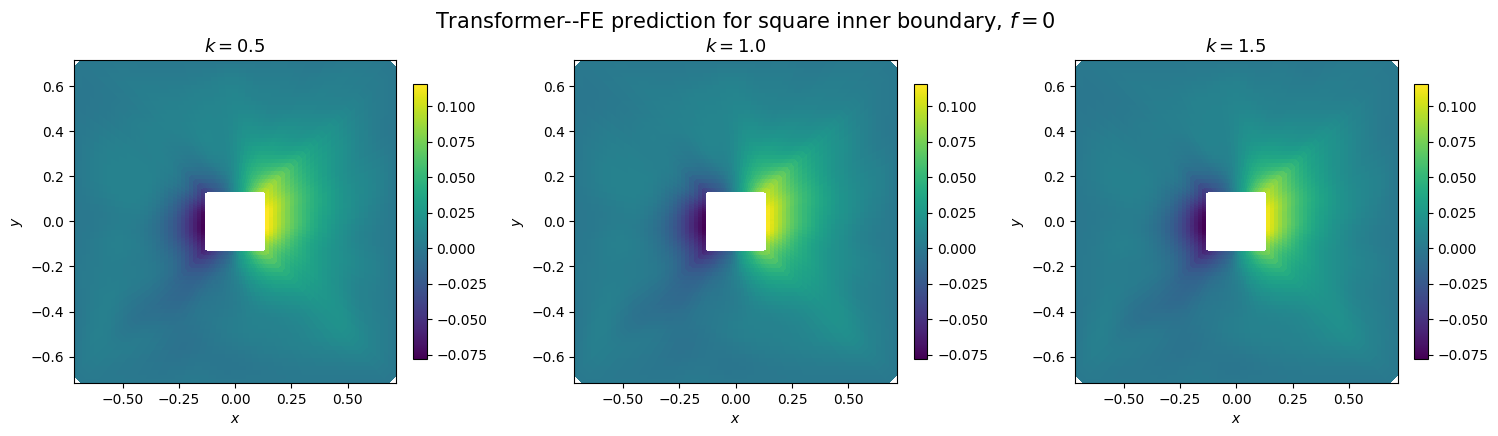

In [21]:
X = close_theta(x_grid)
Y = close_theta(y_grid)
U = close_theta(u_pred_grid)

u_min = np.min(U)
u_max = np.max(U)

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4.2),
    constrained_layout=True,
)

for i, ax in enumerate(axes):
    pcm = ax.pcolormesh(
        X,
        Y,
        U[i],
        shading="auto",
        vmin=u_min,
        vmax=u_max,
    )

    ax.set_aspect("equal")
    ax.set_title(rf"$k={k_values[i]:.1f}$", fontsize=13)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")

    fig.colorbar(pcm, ax=ax, shrink=0.85)

fig.suptitle(
    r"Transformer--FE prediction for square inner boundary, $f=0$",
    fontsize=15,
)

plt.show()

### 内边界为五边形，预测解的分布

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "5"   
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.75"

import sys
from pathlib import Path
import numpy as np

import jax
import jax.numpy as jnp
from flax import serialization
from scipy.io import savemat

PROJECT_DIR = "/home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/var_boundary_sno_code"
sys.path.append(PROJECT_DIR)

from config_varboundary import VarBoundaryConfig
from data_varboundary import (
    SampleBatch,
    GeometryParams,
    make_canonical_grid,
    make_theta,
    normalize_f,
    denormalize_u,
    make_source_tokens,
    make_condition_tokens,
)
from models_varboundary import FunctionEncoder
from train_varboundary import (
    create_fe_state,
    create_ol_state,
    load_field_normalizer,
)

print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


In [2]:
cfg = VarBoundaryConfig()

# 输出目录
cfg.out_dir = "/home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out"
cfg.run_name = "test1"

# PDE parameter range. If fixed k is desired, set k_min = k_max. maybe (0.2, 2.0).
cfg.k_min = 0.2
cfg.k_max = 2.0

# PI-sampler priors
cfg.sample_size = 128
cfg.num_repeats = 6

# Training
cfg.fe_steps = 300_000
cfg.ol_steps = 200_000

out_dir = cfg.output_dir
print("Output dir:", out_dir)

Output dir: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1


In [3]:
normalizer = load_field_normalizer(out_dir)

print("[Normalizer]")
print("mean_u =", float(normalizer.mean_u))
print("std_u  =", float(normalizer.std_u))
print("mean_f =", float(normalizer.mean_f))
print("std_f  =", float(normalizer.std_f))


key = jax.random.PRNGKey(cfg.seed + 20260531)
key, key_fe_init, key_ol_init = jax.random.split(key, 3)

fe_state, _ = create_fe_state(cfg, key_fe_init)

fe_path = out_dir / "fe_params.msgpack"
if not fe_path.exists():
    raise FileNotFoundError(f"Cannot find FE params: {fe_path}")

fe_params = serialization.from_bytes(
    fe_state.params,
    fe_path.read_bytes(),
)

fe_state = fe_state.replace(params=fe_params)

print("Loaded FE params from:", fe_path)


ol_state, _ = create_ol_state(cfg, key_ol_init)

ol_path = out_dir / "ol_params.msgpack"
if not ol_path.exists():
    raise FileNotFoundError(f"Cannot find OL params: {ol_path}")

ol_params = serialization.from_bytes(
    ol_state.params,
    ol_path.read_bytes(),
)

ol_state = ol_state.replace(params=ol_params)

print("Loaded OL params from:", ol_path)

[Normalizer]
mean_u = -1.591348700458184e-05
std_u  = 0.28429415822029114
mean_f = -0.008345461450517178
std_f  = 57.519596099853516


E0603 14:57:12.622715  731477 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[4096,512]{1,0} fusion(args_0_.1, args_1_.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0603 14:57:12.622814  731477 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[4096,514]{1,0} parameter(0)
  parameter_1 = f32[514,512]{1,0} parameter(1)
  ROOT dot_general.0 = f32[4096,512]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["64"]}
}
E0603 14:57:12.635400  731500 x

Loaded FE params from: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/fe_params.msgpack


E0603 14:57:19.494790  731496 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.1 = f32[8,65,65]{2,1,0} fusion(bitcast.11, bitcast.10), kind=kCustom, calls=gemm_fusion_dot.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0603 14:57:19.494877  731496 xtile_compiler.cc:401] Computation: gemm_fusion_dot.1_computation.clone {
  parameter_0 = f32[65,8,64]{2,1,0} parameter(0)
  transpose.4 = f32[8,65,64]{2,1,0} transpose(parameter_0), dimensions={1,0,2}
  parameter_1 = f32[65,8,64]{2,1,0} parameter(1)
  transpose.5 = f32[8,64,65]{2,1,0} transpose(parameter_1), dimensions={1,2,0}
  ROOT dot.2 = f32[8,65,65]{2,1,0} dot(trans

Loaded OL params from: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/ol_params.msgpack


In [4]:
def wrap_to_pi(angle):
    """Map angle to (-pi, pi]."""
    return (angle + np.pi) % (2.0 * np.pi) - np.pi


def regular_polygon_radius_and_derivative(
    theta_np,
    n_sides=5,
    corner_radius=0.2,
    rotation=0.0,
    vertex_tol=1.0e-8,
):
    """
    Regular n-gon centered at origin.

    Parameters
    ----------
    theta_np : array
        Polar angles.
    n_sides : int
        Number of polygon sides.
    corner_radius : float
        Distance from center to each vertex, i.e. circumradius.
    rotation : float
        Rotation angle of the polygon. rotation=0 means one vertex lies on +x axis.
    vertex_tol : float
        Tolerance for detecting vertices, where derivative is set to 0.

    Returns
    -------
    a : array
        Radial boundary a(theta).
    adot : array
        Derivative da/dtheta. At vertices, set to zero.
    vertex_mask : array[bool]
        Detected vertex locations.
    side_index : array[int]
        Which side controls each theta.
    """
    theta_np = np.asarray(theta_np, dtype=np.float64)

    n = int(n_sides)
    Rc = float(corner_radius)

    # Apothem: distance from center to each side
    apothem = Rc * np.cos(np.pi / n)

    # Work in rotated coordinates.
    # rotation=0: vertices at 2*pi*j/n.
    theta_rel = wrap_to_pi(theta_np - rotation)

    # Side outward normal angles are halfway between adjacent vertices:
    # alpha_j = (2j+1)*pi/n
    # We find the nearest side normal alpha_j.
    alpha0 = np.pi / n

    # Map theta_rel near one of the side normals.
    side_index = np.floor((theta_rel - alpha0 + np.pi / n) / (2.0 * np.pi / n)).astype(int)
    side_index = np.mod(side_index, n)

    alpha = alpha0 + side_index * (2.0 * np.pi / n)

    delta = wrap_to_pi(theta_rel - alpha)

    # For a regular polygon, within each side sector:
    # |delta| <= pi/n
    cos_delta = np.cos(delta)

    a = apothem / cos_delta

    # derivative w.r.t theta:
    # a = apothem sec(delta)
    # da/dtheta = apothem sec(delta) tan(delta)
    #            = apothem sin(delta) / cos(delta)^2
    adot = apothem * np.sin(delta) / (cos_delta**2 + 1.0e-12)

    # Vertices are at theta_rel = 2*pi*j/n.
    # Equivalent: |delta| = pi/n.
    vertex_mask = np.abs(np.abs(delta) - np.pi / n) < vertex_tol

    # User convention: derivative at corners is zero.
    adot[vertex_mask] = 0.0

    return (
        a.astype(np.float32),
        adot.astype(np.float32),
        vertex_mask,
        side_index,
    )

In [5]:
theta = np.asarray(jax.device_get(make_theta(cfg)[:, 0]))  # [Nt]
Nt = cfg.theta_size

n_sides = 5
corner_radius = 0.2
rotation = np.pi / 10.0       # 一个顶点在 +x 方向
vertex_tol = 1.0e-8

a_theta, adot_theta, vertex_mask, side_index = regular_polygon_radius_and_derivative(
    theta,
    n_sides=n_sides,
    corner_radius=corner_radius,
    rotation=rotation,
    vertex_tol=vertex_tol,
)

# Problem-defined boundary RHS:
# g(theta) = cos(theta) + adot/a * sin(theta)
g_theta = np.cos(theta) + (adot_theta / a_theta) * np.sin(theta)

# Boundary coordinates
xb = a_theta * np.cos(theta)
yb = a_theta * np.sin(theta)

boundary_coords_single = np.stack([xb, yb], axis=-1).astype(np.float32)  # [Nt, 2]
boundary_flux_single = g_theta.astype(np.float32)                        # [Nt]

apothem = corner_radius * np.cos(np.pi / n_sides)

print("n_sides:", n_sides)
print("corner_radius:", corner_radius)
print("apothem:", apothem)
print("a_theta min/max:", float(a_theta.min()), float(a_theta.max()))
print("number of detected vertices:", int(vertex_mask.sum()))
print("boundary_flux min/max:", float(boundary_flux_single.min()), float(boundary_flux_single.max()))

n_sides: 5
corner_radius: 0.2
apothem: 0.1618033988749895
a_theta min/max: 0.16180339455604553 0.19999998807907104
number of detected vertices: 0
boundary_flux min/max: -1.167300820350647 1.167300820350647


In [6]:
pod_coords = make_canonical_grid(cfg)   # [Npod, 2]
Npod = pod_coords.shape[0]

Nr = cfg.radial_size
Nt = cfg.theta_size

pod_coords_np = np.asarray(jax.device_get(pod_coords))

rho_grid = np.sqrt(
    pod_coords_np[:, 0] ** 2
    + pod_coords_np[:, 1] ** 2
)

theta_grid = np.arctan2(
    pod_coords_np[:, 1],
    pod_coords_np[:, 0],
)

a_grid, adot_grid, vertex_mask_grid, side_index_grid = regular_polygon_radius_and_derivative(
    theta_grid,
    n_sides=n_sides,
    corner_radius=corner_radius,
    rotation=rotation,
    vertex_tol=vertex_tol,
)

r_phys = cfg.outer_scale * rho_grid * a_grid

x_phys = r_phys * np.cos(theta_grid)
y_phys = r_phys * np.sin(theta_grid)

x_phys_grid = x_phys.reshape(Nr, Nt).astype(np.float32)
y_phys_grid = y_phys.reshape(Nr, Nt).astype(np.float32)

print("pod_coords:", pod_coords.shape)
print("x_phys_grid:", x_phys_grid.shape)
print("y_phys_grid:", y_phys_grid.shape)
print("physical radius min/max:", float(r_phys.min()), float(r_phys.max()))

pod_coords: (4096, 2)
x_phys_grid: (32, 128)
y_phys_grid: (32, 128)
physical radius min/max: 0.16180339455604553 0.9999999403953552


In [7]:
k_values = jnp.asarray([0.5, 1.0, 1.5], dtype=jnp.float32)
B = k_values.shape[0]

f_zero_pod = jnp.zeros((B, Npod), dtype=jnp.float32)
f_zero_pod_norm = normalize_f(f_zero_pod, normalizer)

boundary_coords = jnp.asarray(
    np.broadcast_to(boundary_coords_single[None, :, :], (B, Nt, 2)),
    dtype=jnp.float32,
)

boundary_flux = jnp.asarray(
    np.broadcast_to(boundary_flux_single[None, :], (B, Nt)),
    dtype=jnp.float32,
)

pod_phys_coords = jnp.asarray(
    np.broadcast_to(
        np.stack([x_phys, y_phys], axis=-1)[None, :, :],
        (B, Npod, 2),
    ),
    dtype=jnp.float32,
)

dummy_geom = GeometryParams(
    w1=jnp.zeros((B, 2, cfg.hidden_geom_bnn), dtype=jnp.float32),
    b1=jnp.zeros((B, 1, cfg.hidden_geom_bnn), dtype=jnp.float32),
    w2=jnp.zeros((B, cfg.hidden_geom_bnn, 1), dtype=jnp.float32),
)

dummy_u = jnp.zeros((B, Npod), dtype=jnp.float32)

batch_pentagon = SampleBatch(
    pod_coords=pod_coords,
    probe_coords=pod_coords,
    pod_phys_coords=pod_phys_coords,
    probe_phys_coords=pod_phys_coords,
    boundary_coords=boundary_coords,
    boundary_flux=boundary_flux,
    u_pod=dummy_u,
    f_pod=f_zero_pod,
    u_probe=dummy_u,
    f_probe=f_zero_pod,
    k_values=k_values,
    geom_params=dummy_geom,
)

In [8]:
def make_fem_reference_grid_from_a_theta(
    a_ref: np.ndarray,
    cfg,
    Nr_tar: int,
    Nt_tar: int,
    refine_r: int = 16,
    refine_theta: int = 32,
):
    """
    Construct a high-resolution grid that matches the MATLAB FEM mesh.

    MATLAB FEM uses:
        theta = linspace(0, 2*pi, Nt_ref+1); theta(end) = [];
        scale = linspace(1.0, outer_scale, Nr_ref);
        r_phys = scale * a(theta)

    FE trunk uses canonical coordinates:
        rho = scale / outer_scale
        x_hat = rho * cos(theta)
        y_hat = rho * sin(theta)

    Parameters
    ----------
    a_ref:
        Array of shape [Nt_ref], inner boundary radius evaluated at theta_ref.
    cfg:
        VarBoundaryConfig.
    Nr_tar, Nt_tar:
        Original neural grid sizes.
    refine_r, refine_theta:
        Refinement factors.

    Returns
    -------
    dict containing:
        Nr_ref, Nt_ref
        theta_ref, scale_ref, rho_ref
        coords_hat_ref_flat: [Nr_ref*Nt_ref, 2]
        x_phys_ref_grid: [Nr_ref, Nt_ref]
        y_phys_ref_grid: [Nr_ref, Nt_ref]
    """
    Nr_ref = refine_r * Nr_tar
    Nt_ref = refine_theta * Nt_tar

    theta_ref = np.linspace(0.0, 2.0 * np.pi, Nt_ref, endpoint=False)
    scale_ref = np.linspace(1.0, float(cfg.outer_scale), Nr_ref)

    # Meshgrid layout matches MATLAB:
    # [Theta, Scale] = meshgrid(theta, scale)
    Theta_ref, Scale_ref = np.meshgrid(theta_ref, scale_ref)

    a_ref_grid = np.broadcast_to(a_ref[None, :], (Nr_ref, Nt_ref))

    # Physical FEM-compatible coordinates
    R_phys_ref = Scale_ref * a_ref_grid
    x_phys_ref_grid = R_phys_ref * np.cos(Theta_ref)
    y_phys_ref_grid = R_phys_ref * np.sin(Theta_ref)

    # Canonical coordinates for FE trunk
    rho_ref = scale_ref / float(cfg.outer_scale)
    Rho_ref, Theta_hat_ref = np.meshgrid(rho_ref, theta_ref, indexing="ij")

    x_hat_ref_grid = Rho_ref * np.cos(Theta_hat_ref)
    y_hat_ref_grid = Rho_ref * np.sin(Theta_hat_ref)

    coords_hat_ref_flat = np.stack(
        [x_hat_ref_grid.reshape(-1), y_hat_ref_grid.reshape(-1)],
        axis=-1,
    ).astype(np.float32)

    return {
        "Nr_ref": Nr_ref,
        "Nt_ref": Nt_ref,
        "theta_ref": theta_ref.astype(np.float32),
        "scale_ref": scale_ref.astype(np.float32),
        "rho_ref": rho_ref.astype(np.float32),
        "coords_hat_ref_flat": coords_hat_ref_flat,
        "x_hat_ref_grid": x_hat_ref_grid.astype(np.float32),
        "y_hat_ref_grid": y_hat_ref_grid.astype(np.float32),
        "x_phys_ref_grid": x_phys_ref_grid.astype(np.float32),
        "y_phys_ref_grid": y_phys_ref_grid.astype(np.float32),
    }


def reconstruct_u_on_ref_grid_chunked(
    fe_state,
    pred_u_latent,
    coords_hat_ref_flat: np.ndarray,
    normalizer,
    chunk_size: int = 65536,
):
    """
    Reconstruct u_pred on high-resolution canonical coordinates.

    pred_u_latent: [B, n_basis]
    coords_hat_ref_flat: [Nref, 2]
    return:
        u_pred_ref_flat: [B, Nref]
    """
    coords_jax = jnp.asarray(coords_hat_ref_flat)
    n_points = coords_hat_ref_flat.shape[0]

    chunks = []

    for start in range(0, n_points, chunk_size):
        end = min(start + chunk_size, n_points)

        coords_chunk = coords_jax[start:end]

        u_chunk_norm = fe_state.apply_fn(
            {"params": fe_state.params},
            pred_u_latent,
            coords_chunk,
            method=FunctionEncoder.reconstruct,
        )

        u_chunk = denormalize_u(u_chunk_norm, normalizer)

        chunks.append(np.asarray(jax.device_get(u_chunk)))

    u_pred_ref_flat = np.concatenate(chunks, axis=1)
    return u_pred_ref_flat

In [9]:
# ============================================================
# 1. FE encode f=0
# ============================================================
latent_f = fe_state.apply_fn(
    {"params": fe_state.params},
    f_zero_pod_norm,
    method=FunctionEncoder.encode_f,
)

# ============================================================
# 2. Build Transformer tokens
# ============================================================
f_tokens = make_source_tokens(latent_f, cfg)
bc_tokens = make_condition_tokens(batch_pentagon, cfg)

print("latent_f:", latent_f.shape)
print("f_tokens:", f_tokens.shape)
print("bc_tokens:", bc_tokens.shape)

# ============================================================
# 3. Transformer predicts u latent
# ============================================================
pred_u_latent = ol_state.apply_fn(
    {"params": ol_state.params},
    f_tokens,
    bc_tokens,
    k_values,
)

# ============================================================
# 4. FE trunk reconstructs u
# ============================================================
u_pred_norm = fe_state.apply_fn(
    {"params": fe_state.params},
    pred_u_latent,
    pod_coords,
    method=FunctionEncoder.reconstruct,
)

u_pred = denormalize_u(u_pred_norm, normalizer)

print("pred_u_latent:", pred_u_latent.shape)
print("u_pred:", u_pred.shape)

# ============================================================
# High-resolution FEM-compatible reconstruction
# ============================================================
Nr_tar = Nr
Nt_tar = Nt

Nr_ref = 16 * Nr_tar
Nt_ref = 32 * Nt_tar

theta_ref = np.linspace(0.0, 2.0 * np.pi, Nt_ref, endpoint=False)

a_ref, adot_ref, vertex_mask_ref, side_index_ref = regular_polygon_radius_and_derivative(
    theta_ref,
    n_sides=n_sides,
    corner_radius=corner_radius,
    rotation=rotation,
    vertex_tol=vertex_tol,
)

ref_grid = make_fem_reference_grid_from_a_theta(
    a_ref=a_ref,
    cfg=cfg,
    Nr_tar=Nr_tar,
    Nt_tar=Nt_tar,
    refine_r=16,
    refine_theta=32,
)

u_pred_ref_flat = reconstruct_u_on_ref_grid_chunked(
    fe_state=fe_state,
    pred_u_latent=pred_u_latent,
    coords_hat_ref_flat=ref_grid["coords_hat_ref_flat"],
    normalizer=normalizer,
    chunk_size=65536,
)

u_pred_ref_grid = u_pred_ref_flat.reshape(B, ref_grid["Nr_ref"], ref_grid["Nt_ref"])

print("u_pred_ref_grid:", u_pred_ref_grid.shape)
print("x_phys_ref_grid:", ref_grid["x_phys_ref_grid"].shape)

latent_f: (3, 512)
f_tokens: (3, 32, 16)
bc_tokens: (3, 32, 12)


E0603 14:58:17.343611  731471 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.1 = f32[24,65,65]{2,1,0} fusion(bitcast.11, bitcast.10), kind=kCustom, calls=gemm_fusion_dot.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0603 14:58:17.343706  731471 xtile_compiler.cc:401] Computation: gemm_fusion_dot.1_computation.clone {
  parameter_0 = f32[24,65,64]{2,1,0} parameter(0)
  parameter_1 = f32[24,64,65]{2,1,0} parameter(1)
  ROOT dot.2 = f32[24,65,65]{2,1,0} dot(parameter_0, parameter_1), lhs_batch_dims={0}, lhs_contracting_dims={2}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backend_config={"sizes":["32"]}
}
E0603 

pred_u_latent: (3, 512)
u_pred: (3, 4096)


E0603 14:58:24.411477  731492 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[65536,512]{1,0} fusion(args_0_.1, args_1_.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["128","128"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0603 14:58:24.411537  731492 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[65536,514]{1,0} parameter(0)
  parameter_1 = f32[514,512]{1,0} parameter(1)
  ROOT dot_general.0 = f32[65536,512]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["32"]}
}
E0603 14:58:24.424411  731

u_pred_ref_grid: (3, 512, 4096)
x_phys_ref_grid: (512, 4096)


/tmp/ipykernel_210460/1114991655.py:42: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(


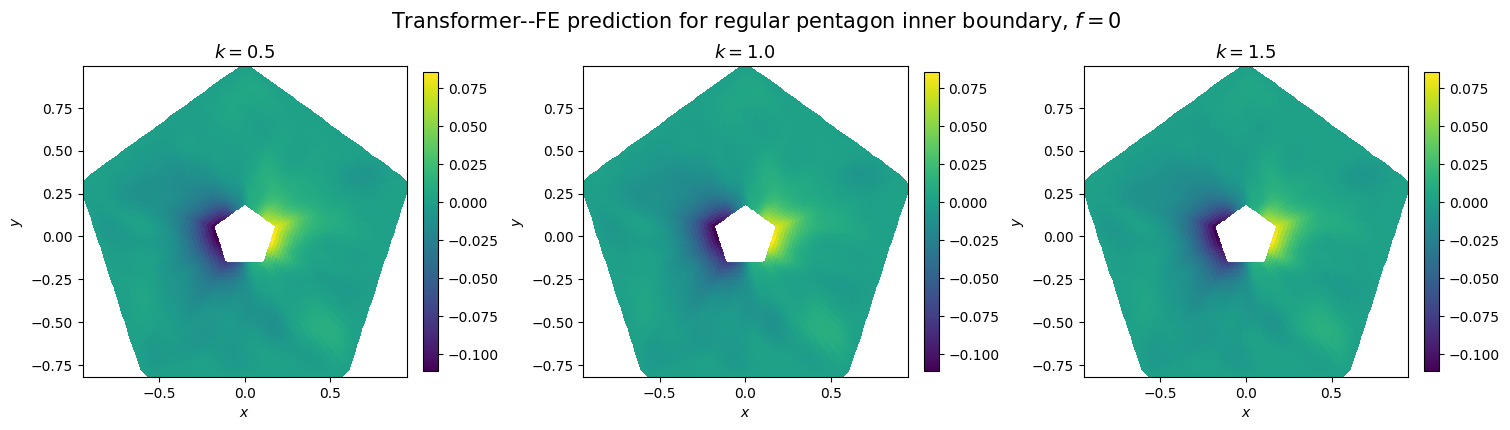

In [9]:
import matplotlib.pyplot as plt

def close_theta_np(A):
    if A.ndim == 2:
        return np.concatenate([A, A[:, :1]], axis=1)
    elif A.ndim == 3:
        return np.concatenate([A, A[:, :, :1]], axis=2)
    else:
        raise ValueError(f"Unsupported ndim: {A.ndim}")


u_pred_np = np.asarray(jax.device_get(u_pred))
u_pred_grid = u_pred_np.reshape(B, Nr, Nt)

X = close_theta_np(x_phys_grid)
Y = close_theta_np(y_phys_grid)
U = close_theta_np(u_pred_grid)

k_values_np = np.asarray(jax.device_get(k_values))

# Boundary curves
x_inner = xb
y_inner = yb
x_outer = cfg.outer_scale * xb
y_outer = cfg.outer_scale * yb

x_inner_closed = np.r_[x_inner, x_inner[0]]
y_inner_closed = np.r_[y_inner, y_inner[0]]
x_outer_closed = np.r_[x_outer, x_outer[0]]
y_outer_closed = np.r_[y_outer, y_outer[0]]

u_min = np.min(U)
u_max = np.max(U)

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4.2),
    constrained_layout=True,
)

for i, ax in enumerate(axes):
    pcm = ax.pcolormesh(
        X,
        Y,
        U[i],
        shading="auto",
        vmin=u_min,
        vmax=u_max,
    )

    # ax.plot(x_inner_closed, y_inner_closed, "k-", linewidth=1.0)
    # ax.plot(x_outer_closed, y_outer_closed, "k-", linewidth=1.0)

    ax.set_aspect("equal")
    ax.set_title(rf"$k={k_values_np[i]:.1f}$", fontsize=13)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")

    fig.colorbar(pcm, ax=ax, shrink=0.85)

fig.suptitle(
    r"Transformer--FE prediction for regular pentagon inner boundary, $f=0$",
    fontsize=15,
)

plt.show()

In [10]:
def to_numpy(x):
    return np.asarray(jax.device_get(x))


u_pred_np = to_numpy(u_pred)
u_pred_grid = u_pred_np.reshape(B, Nr, Nt)

f_grid = np.zeros((B, Nr, Nt), dtype=np.float32)

k_values_np = to_numpy(k_values)

mat_path = out_dir / "pentagon_vertex_on_y_corner_radius_0p2_f0_problem_flux_transformer_fe_k_0p5_1p0_1p5_fem_refgrid.mat"

savemat(
    mat_path,
    {
        # Metadata
        "num_cases": np.array([[B]]),
        "radial_size": np.array([[Nr]]),
        "theta_size": np.array([[Nt]]),
        "n_basis": np.array([[cfg.n_basis]]),

        # Geometry information
        "geometry_type": np.array(["regular_pentagon_corner_derivative_zero"], dtype=object),
        "n_sides": np.array([[n_sides]], dtype=np.int32),
        "corner_radius": np.array([[corner_radius]], dtype=np.float32),
        "apothem": np.array([[apothem]], dtype=np.float32),
        "rotation": np.array([[rotation]], dtype=np.float32),
        "outer_scale": np.array([[cfg.outer_scale]], dtype=np.float32),

        # theta-dependent geometry
        "theta": theta[:, None].astype(np.float32),
        "a_theta": a_theta[:, None].astype(np.float32),
        "adot_theta": adot_theta[:, None].astype(np.float32),
        "vertex_mask": vertex_mask[:, None].astype(np.float32),
        "side_index": side_index[:, None].astype(np.int32),

        # Boundary condition
        "boundary_flux": boundary_flux_single[:, None].astype(np.float32),
        "boundary_coords": boundary_coords_single.astype(np.float32),

        # Coordinates
        "pod_coords": pod_coords_np.astype(np.float32),
        "x_phys_grid": x_phys_grid,
        "y_phys_grid": y_phys_grid,

        # PDE input
        "k_values": k_values_np[:, None],
        "f_grid": f_grid,

        # Prediction
        "u_pred_pod": u_pred_np.astype(np.float32),
        "u_pred_grid": u_pred_grid.astype(np.float32),

        # Latent
        "latent_f": to_numpy(latent_f),
        "pred_u_latent": to_numpy(pred_u_latent),

        # Normalizer
        "norm_mean_u": np.array([[float(normalizer.mean_u)]], dtype=np.float32),
        "norm_std_u": np.array([[float(normalizer.std_u)]], dtype=np.float32),
        "norm_mean_f": np.array([[float(normalizer.mean_f)]], dtype=np.float32),
        "norm_std_f": np.array([[float(normalizer.std_f)]], dtype=np.float32),

        # High-resolution FEM-compatible geometry
        "theta_ref": ref_grid["theta_ref"][:, None],
        "a_ref": a_ref[:, None].astype(np.float32),
        "adot_ref": adot_ref[:, None].astype(np.float32),
        "vertex_mask_ref": vertex_mask_ref[:, None].astype(np.float32),
        "side_index_ref": side_index_ref[:, None].astype(np.int32),
        
        # High-resolution FEM-compatible coordinates and prediction
        "Nr_ref": np.array([[ref_grid["Nr_ref"]]], dtype=np.int32),
        "Nt_ref": np.array([[ref_grid["Nt_ref"]]], dtype=np.int32),
        "scale_ref": ref_grid["scale_ref"][:, None],
        "rho_ref": ref_grid["rho_ref"][:, None],
        
        "x_hat_ref_grid": ref_grid["x_hat_ref_grid"],
        "y_hat_ref_grid": ref_grid["y_hat_ref_grid"],
        "x_phys_ref_grid": ref_grid["x_phys_ref_grid"],
        "y_phys_ref_grid": ref_grid["y_phys_ref_grid"],
        
        "u_pred_ref_pod": u_pred_ref_flat.astype(np.float32),
        "u_pred_ref_grid": u_pred_ref_grid.astype(np.float32),
    },
    do_compression=True,
)

print("Saved:", mat_path)

Saved: /home/user/data/Hollon/海洋工程水动力/var_boundary_sno_code/out/test1/pentagon_vertex_on_y_corner_radius_0p2_f0_problem_flux_transformer_fe_k_0p5_1p0_1p5_fem_refgrid.mat
